# IS6052 - Predictive Analytics Group Project - Group 23

##### David Dillane: 118470882
##### Ansh Jadav: 125119712
##### Joseph Kadam: 125105066
##### Srishti Singh: 124133552
##### Vraj Jariwala: 125117215

# 1. Dataset description and Initial Exploration 

##### Importing necessary libraries required. (If installed already please ignore)

In [ ]:
!pip install lime
!pip install shap
pip install tensorflow
!pip install xgboost
pip install scikit-optimize

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

In [35]:
print(os.getcwd())

C:\Windows\System32\Srishti\IS6052\Final


In [3]:
warnings.filterwarnings('ignore')


In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)


In [36]:
df = pd.read_csv(r'Omni_Churn_Data.csv') #Change the filepath according to what you got on [35]
print(f"Dataset shape: {df.shape}")

Dataset shape: (50000, 35)


In [8]:
print("First 10 rows of the dataset:")
df.head(10)
print("Last 5 rows of the dataset:")
df.tail()
print("Dataset Information:")
print("="*80)
df.info()
print(f"\nDataset Dimensions:")
print(f"Number of Records: {df.shape[0]:,}")
print(f"Number of Variables: {df.shape[1]}")
print("\nColumn Names:")
print("="*80)
for idx, col in enumerate(df.columns, 1):
    print(f"{idx:2d}. {col}")

First 10 rows of the dataset:
Last 5 rows of the dataset:
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                50000 non-null  int64  
 1   Age                       49975 non-null  float64
 2   Gender                    50000 non-null  object 
 3   IncomeTier                49800 non-null  object 
 4   Region                    50000 non-null  object 
 5   Education                 49980 non-null  object 
 6   ContractLength            50000 non-null  object 
 7   PaymentMethod             50000 non-null  object 
 8   PlanType                  50000 non-null  object 
 9   TenureMonths              50000 non-null  float64
 10  MonthlyCharges            49990 non-null  float64
 11  TotalCharges              49990 non-null  float64
 12  LoginsLastMonth           50000 non-n

Dataset Description:

The Omni Company churn dataset contains 50,000 customer records with 35 variables with multiple categories:

Variable Categories:
1.Customer Profile & Demographics (6 variables)-
  CustomerID, Age, Gender, IncomeTier, Region, Education

2.Account & Contract Information (9 variables)-
  ContractLength, PlanType, PaymentMethod, TenureMonths, ContractAutoRenew, AutoPay, PaymentDelinquencyStatus, Paperless

3.Usage & Spend Metrics (6 variables)-
  MonthlyCharges, TotalCharges, LoginsLastMonth, RFMScore, UsageChangePct, CompetitorIndex

4.Engagement & Support (5 variables)-
  TicketsOpened, TicketsResolutionTime, SupportChannelPreferred, ComplaintCategory

5.Products & Bundles (5 variables)-
  FamilyPlan, AddOnBundle, DiscountType, PromoCodeUsed

6.Acquisition & Device Preferences (4 variables)-
   ReferralSource, ChannelPreferred, DeviceType, DeviceOS, CityTier, CustomerSegment

7.Target Variable-
  Churn (0 = No churn, 1 = Churn)


In [34]:
print("Missing Values Analysis:")
print("="*80)
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Column': missing_values.index,'Missing_Count': missing_values.values,'Missing_Percentage': missing_percentage.values})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found in the dataset!")

Missing Values Analysis:
           Column  Missing_Count  Missing_Percentage
       IncomeTier            200               0.400
              Age             25               0.050
       DeviceType             24               0.048
      AddOnBundle             22               0.044
        Education             20               0.040
 ChannelPreferred             15               0.030
   MonthlyCharges             10               0.020
     TotalCharges             10               0.020
       FamilyPlan              9               0.018
ComplaintCategory              3               0.006
    PromoCodeUsed              3               0.006
     DiscountType              2               0.004


In [9]:
duplicates = df.duplicated().sum()
print(f"\nDuplicate Records: {duplicates}")

if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")
duplicate_ids = df['CustomerID'].duplicated().sum()
print(f"\nDuplicate CustomerIDs: {duplicate_ids}")



Duplicate Records: 0

Duplicate CustomerIDs: 0


In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
if 'CustomerID' in numerical_cols:
    numerical_cols.remove('CustomerID')

print(f"Numerical Columns ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols)

Numerical Columns (11):
['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'LoginsLastMonth', 'TicketsOpened', 'TicketsResolutionTime', 'RFMScore', 'UsageChangePct', 'CompetitorIndex', 'Churn']

Categorical Columns (23):
['Gender', 'IncomeTier', 'Region', 'Education', 'ContractLength', 'PaymentMethod', 'PlanType', 'DeviceType', 'ChannelPreferred', 'CustomerSegment', 'AutoPay', 'Paperless', 'FamilyPlan', 'AddOnBundle', 'ReferralSource', 'SupportChannelPreferred', 'ComplaintCategory', 'DiscountType', 'ContractAutoRenew', 'DeviceOS', 'CityTier', 'PromoCodeUsed', 'PaymentDelinquencyStatus']


Target Variable Analysis:

Understanding the distribution of our target variable (Churn) is crucial for model development and evaluation.

In [16]:
print("Churn Distribution:")
print("="*80)
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({'Churn_Status': ['No Churn (0)', 'Churn (1)'],'Count': churn_counts.values,'Percentage': churn_percentages.values})
print(churn_summary.to_string(index=False))

churn_rate = churn_percentages[1]
print(f"\nOverall Churn Rate: {churn_rate:.2f}%")


Churn Distribution:
Churn_Status  Count  Percentage
No Churn (0)  37000      74.000
   Churn (1)  13000      26.000

Overall Churn Rate: 26.00%


In [17]:
# Checking for class imbalance
if churn_rate < 40 or churn_rate > 60:
    print(f"\n Class Imbalance Detected! The dataset shows imbalanced classes.")
    print(f"This may require special handling techniques such as:")
    print("- Class weights in model training")
    print("- Stratified sampling in cross-validation")
else:
    print("\n Classes are relatively balanced.")



 Class Imbalance Detected! The dataset shows imbalanced classes.
This may require special handling techniques such as:
- Class weights in model training
- Stratified sampling in cross-validation


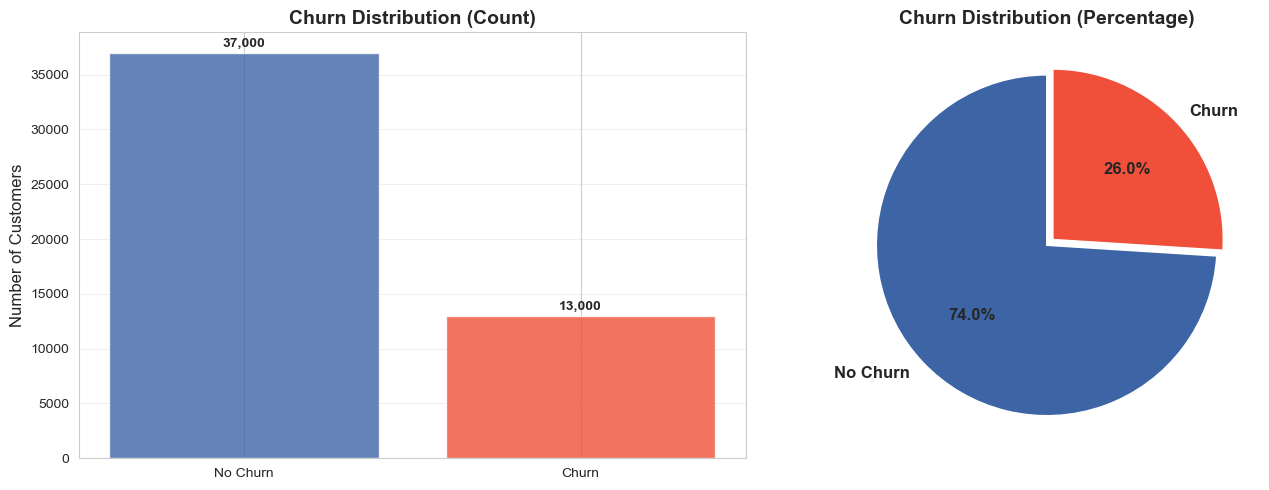

In [18]:
# Visualizing churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['No Churn', 'Churn'], churn_counts.values, color=['#3D65A5','#F05039' ], alpha=0.8)
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

colors = ['#3D65A5', '#F05039']
explode = (0, 0.05)
axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=colors, explode=explode, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Numerical Features Analysis:

We examine the distribution and statistical properties of numerical variables to understand their characteristics and relationships with churn.

In [19]:
print("Descriptive Statistics for Numerical Features:")
print("="*80)
df[numerical_cols].describe().T

Descriptive Statistics for Numerical Features:


,count,mean,std,min,25%,50%,75%,max
Age,49975.000,49.120,18.711,18.000,35.000,49.000,63.000,199.477
TenureMonths,50000.000,60.609,41.072,0.000,30.000,60.000,90.000,989.000
MonthlyCharges,49990.000,107.096,89.278,10.000,62.593,105.165,148.028,4859.018
TotalCharges,49990.000,6418.154,7802.045,-469.113,2256.420,4913.795,8986.613,464256.369
LoginsLastMonth,50000.000,50.819,46.669,0.000,24.000,49.000,75.000,1980.000
TicketsOpened,50000.000,9.480,5.768,0.000,4.000,9.000,14.000,19.000
TicketsResolutionTime,50000.000,36.671,22.227,0.500,18.459,36.484,54.257,464.125
RFMScore,50000.000,7.530,4.036,1.000,4.000,8.000,11.000,14.000
UsageChangePct,50000.000,0.007,0.600,-8.474,-0.496,0.002,0.505,9.606
CompetitorIndex,50000.000,0.506,0.335,0.000,0.250,0.500,0.750,9.816


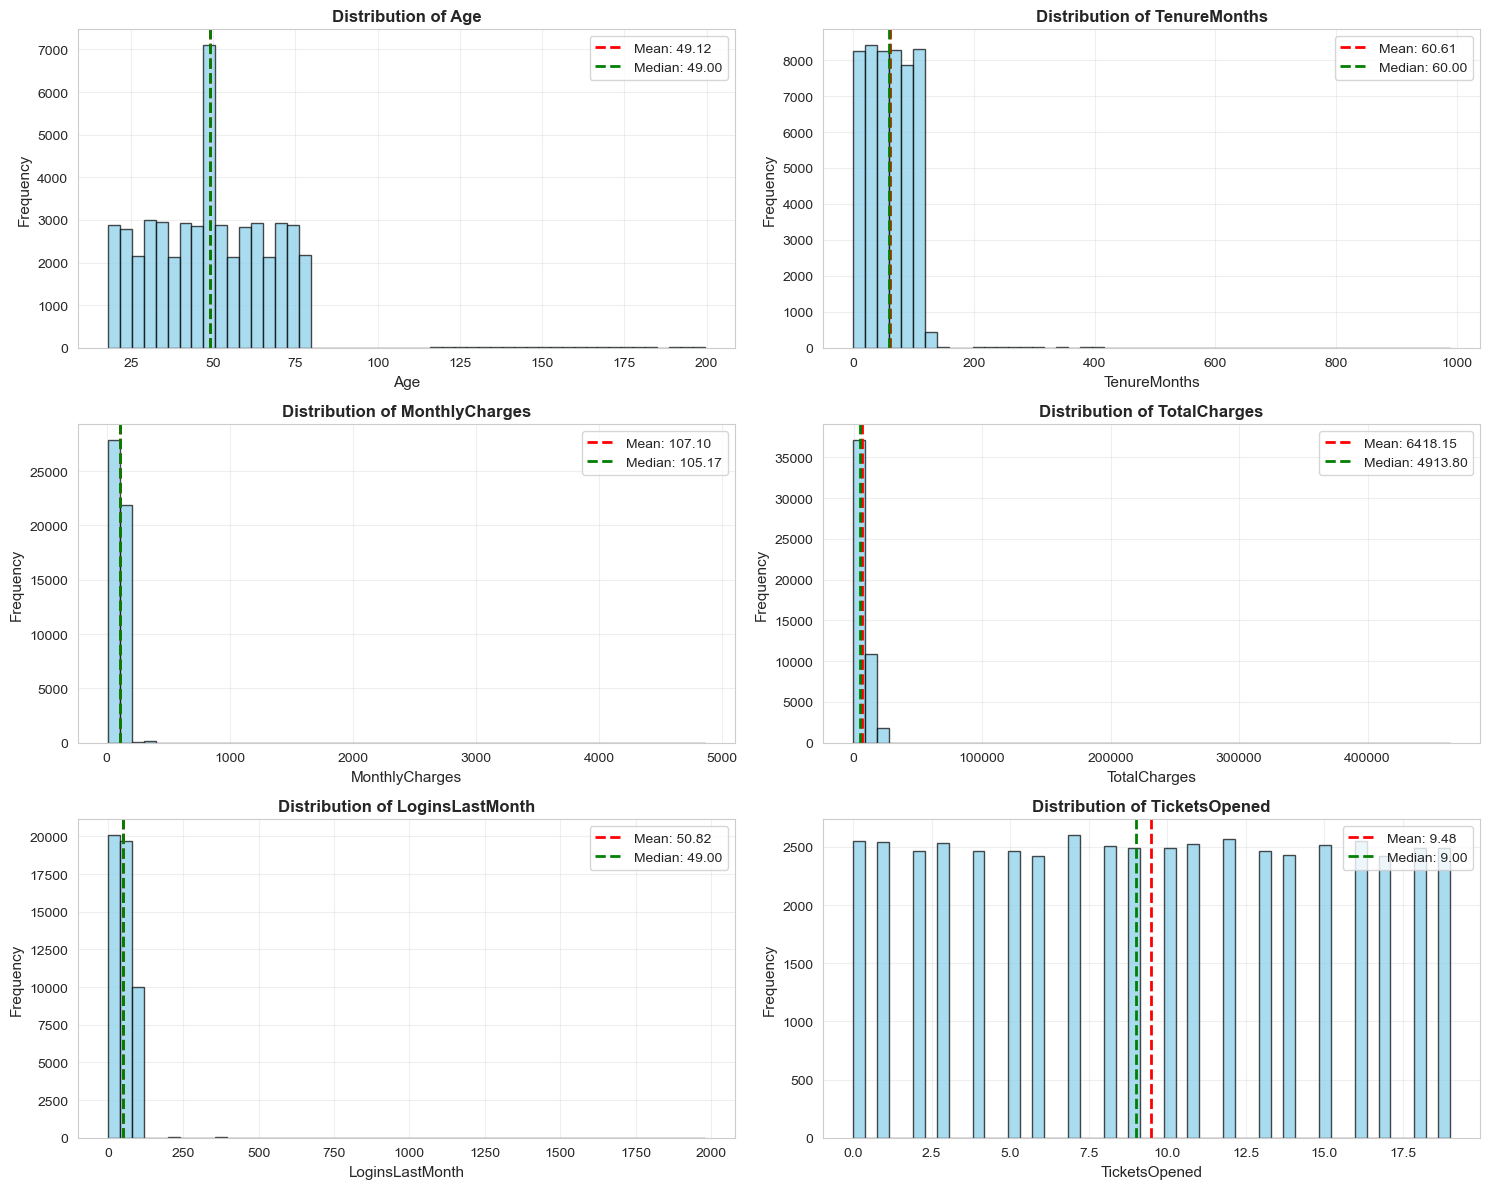

In [20]:
# Visualize distributions of key numerical features
key_numerical = ['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'LoginsLastMonth', 'TicketsOpened']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(key_numerical):
    if col in df.columns:
        axes[idx].hist(df[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
        axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.2f}')
        axes[idx].set_xlabel(col, fontsize=11)
        axes[idx].set_ylabel('Frequency', fontsize=11)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

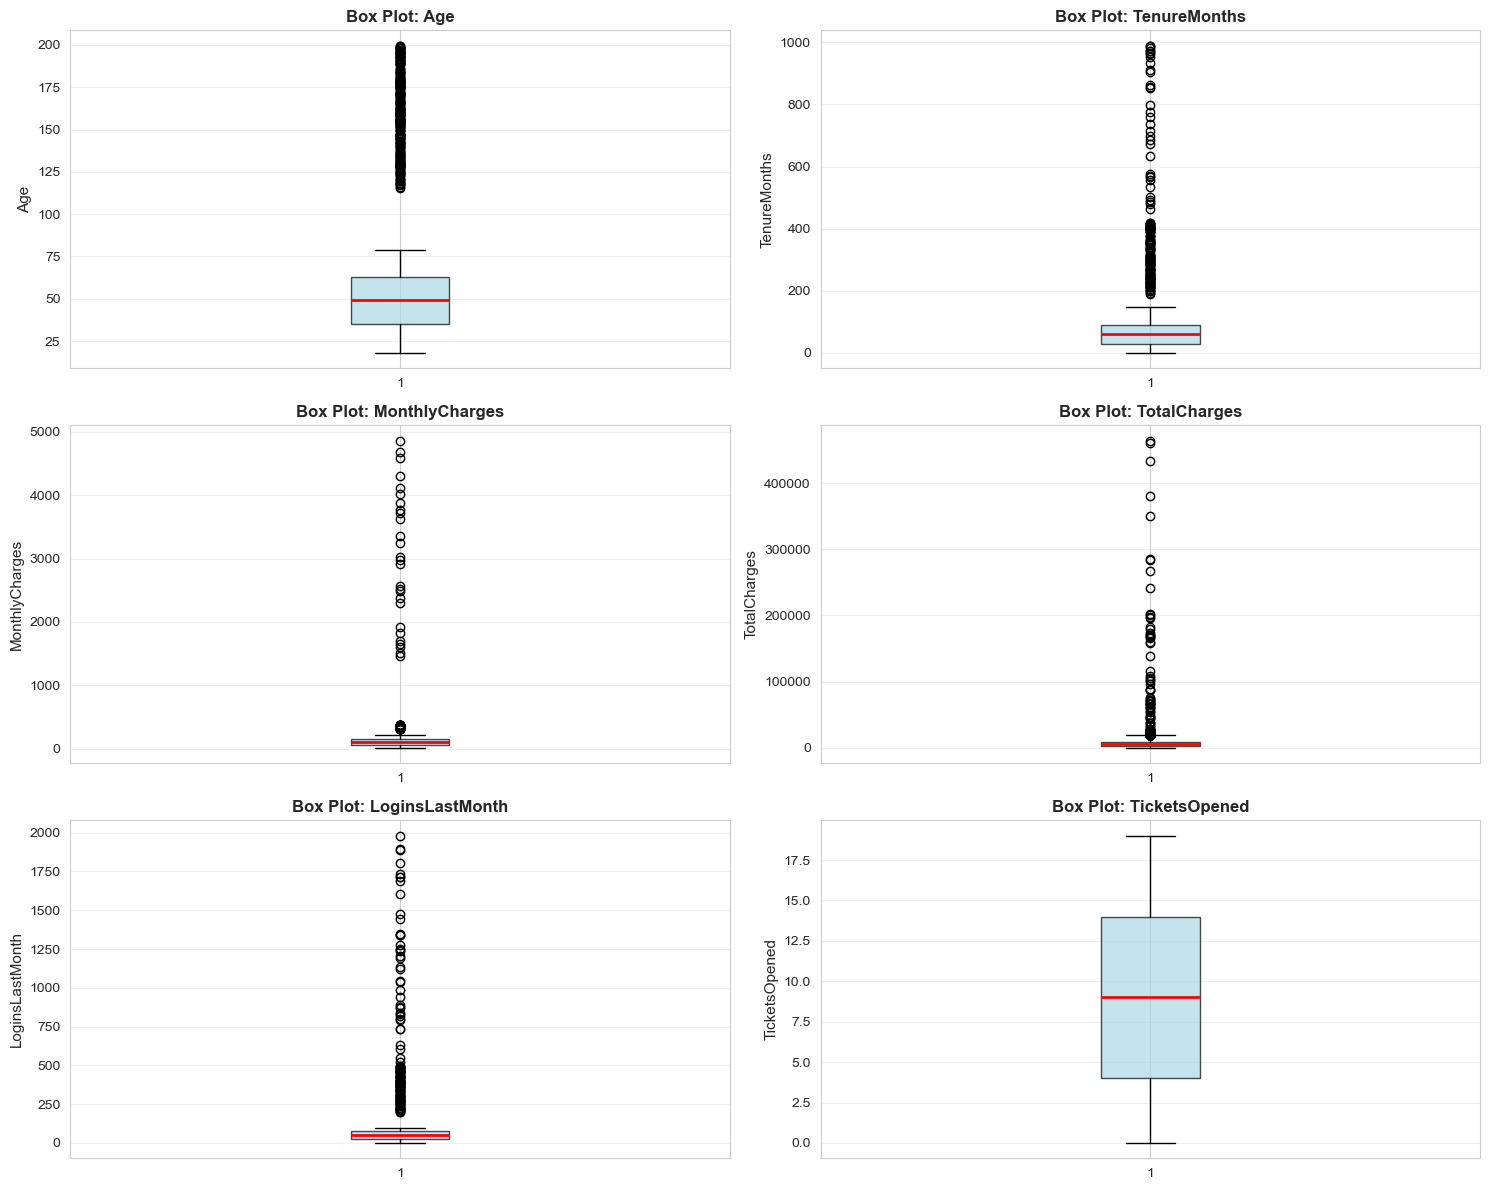

In [42]:
# Box plots to identify potential outliers
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(key_numerical):
    if col in df.columns:
        axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7), medianprops=dict(color='red', linewidth=2))
        axes[idx].set_ylabel(col, fontsize=11)
        axes[idx].set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

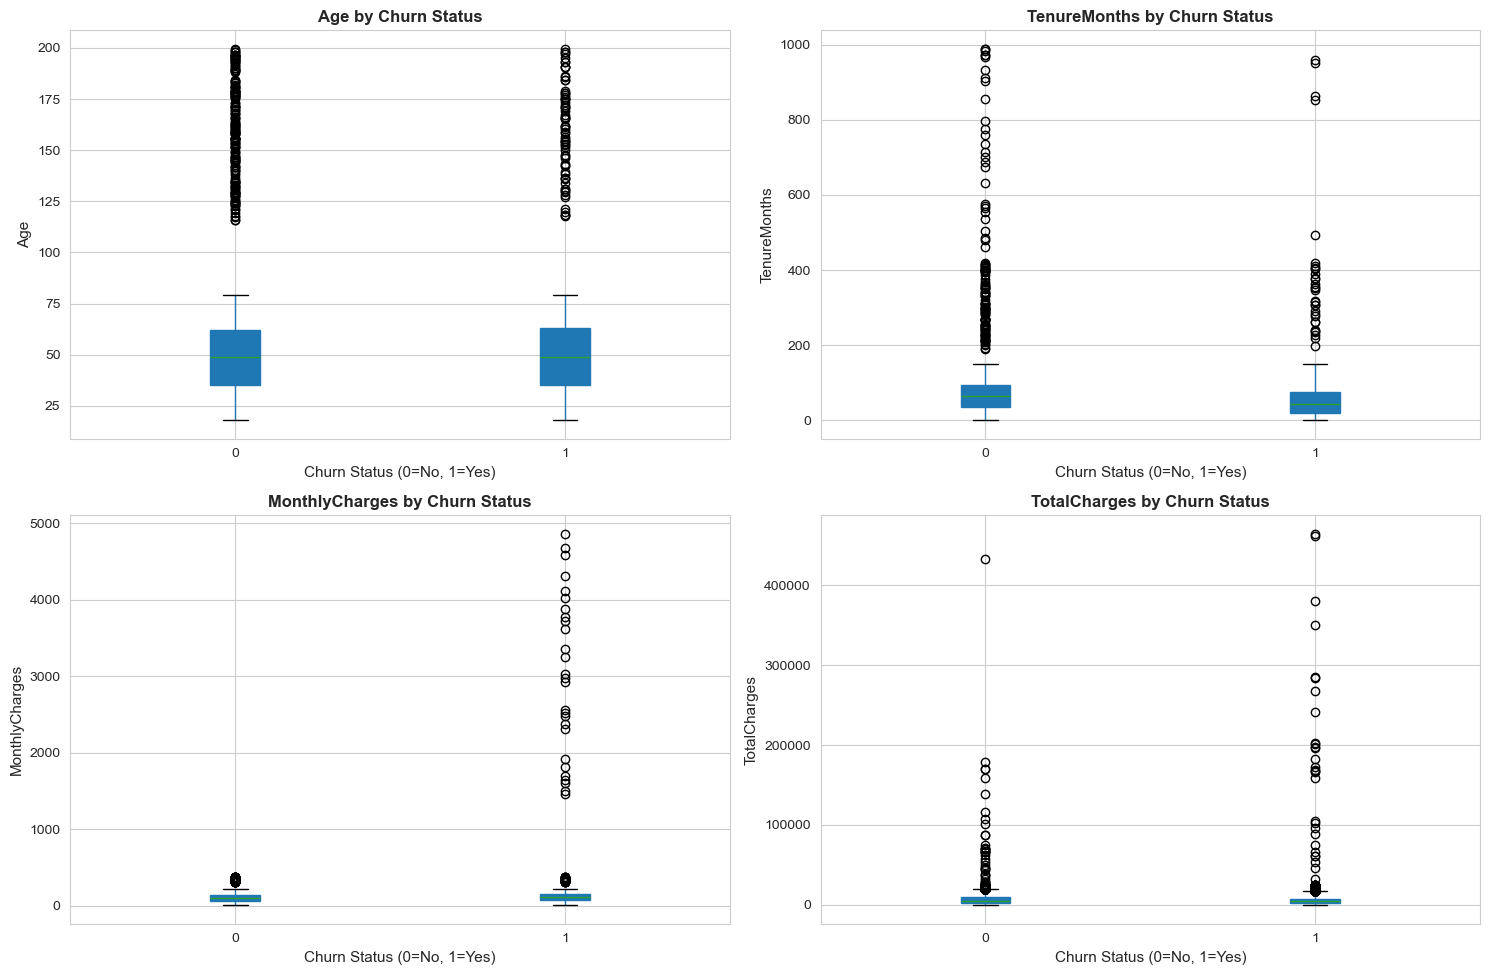

In [22]:
# Compare numerical features across churn status
comparison_features = ['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(comparison_features):
    if col in df.columns:
        df.boxplot(column=col, by='Churn', ax=axes[idx], patch_artist=True)
        axes[idx].set_xlabel('Churn Status (0=No, 1=Yes)', fontsize=11)
        axes[idx].set_ylabel(col, fontsize=11)
        axes[idx].set_title(f'{col} by Churn Status', fontsize=12, fontweight='bold')
        axes[idx].get_figure().suptitle('')  # Removing default title

plt.tight_layout()
plt.show()


In [23]:
# Statistical comparison of numerical features by churn status
print("Numerical Features Comparison: Churned vs Non-Churned Customers")
print("="*80)

for col in comparison_features:
    if col in df.columns:
        no_churn_mean = df[df['Churn'] == 0][col].mean()
        churn_mean = df[df['Churn'] == 1][col].mean()
        difference = churn_mean - no_churn_mean
        pct_difference = (difference / no_churn_mean) * 100
        
        print(f"\n{col}:")
        print(f"  No Churn (Mean): {no_churn_mean:.2f}")
        print(f"  Churn (Mean): {churn_mean:.2f}")
        print(f"  Difference: {difference:.2f} ({pct_difference:+.1f}%)")


Numerical Features Comparison: Churned vs Non-Churned Customers

Age:
  No Churn (Mean): 49.04
  Churn (Mean): 49.34
  Difference: 0.30 (+0.6%)

TenureMonths:
  No Churn (Mean): 64.59
  Churn (Mean): 49.28
  Difference: -15.31 (-23.7%)

MonthlyCharges:
  No Churn (Mean): 102.06
  Churn (Mean): 121.44
  Difference: 19.38 (+19.0%)

TotalCharges:
  No Churn (Mean): 6562.99
  Churn (Mean): 6005.83
  Difference: -557.15 (-8.5%)


In [24]:
# Correlation matrix for numerical features
print("Correlation Matrix:")
print("="*80)

# Calculating correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Displaying correlations with Churn
if 'Churn' in numerical_cols:
    churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)
    print("\nCorrelations with Churn (sorted):")
    print(churn_correlations)


Correlation Matrix:

Correlations with Churn (sorted):
Churn                    1.000
CompetitorIndex          0.127
TicketsOpened            0.114
MonthlyCharges           0.095
TicketsResolutionTime    0.075
Age                      0.007
RFMScore                 0.001
LoginsLastMonth         -0.006
TotalCharges            -0.031
UsageChangePct          -0.104
TenureMonths            -0.164
Name: Churn, dtype: float64


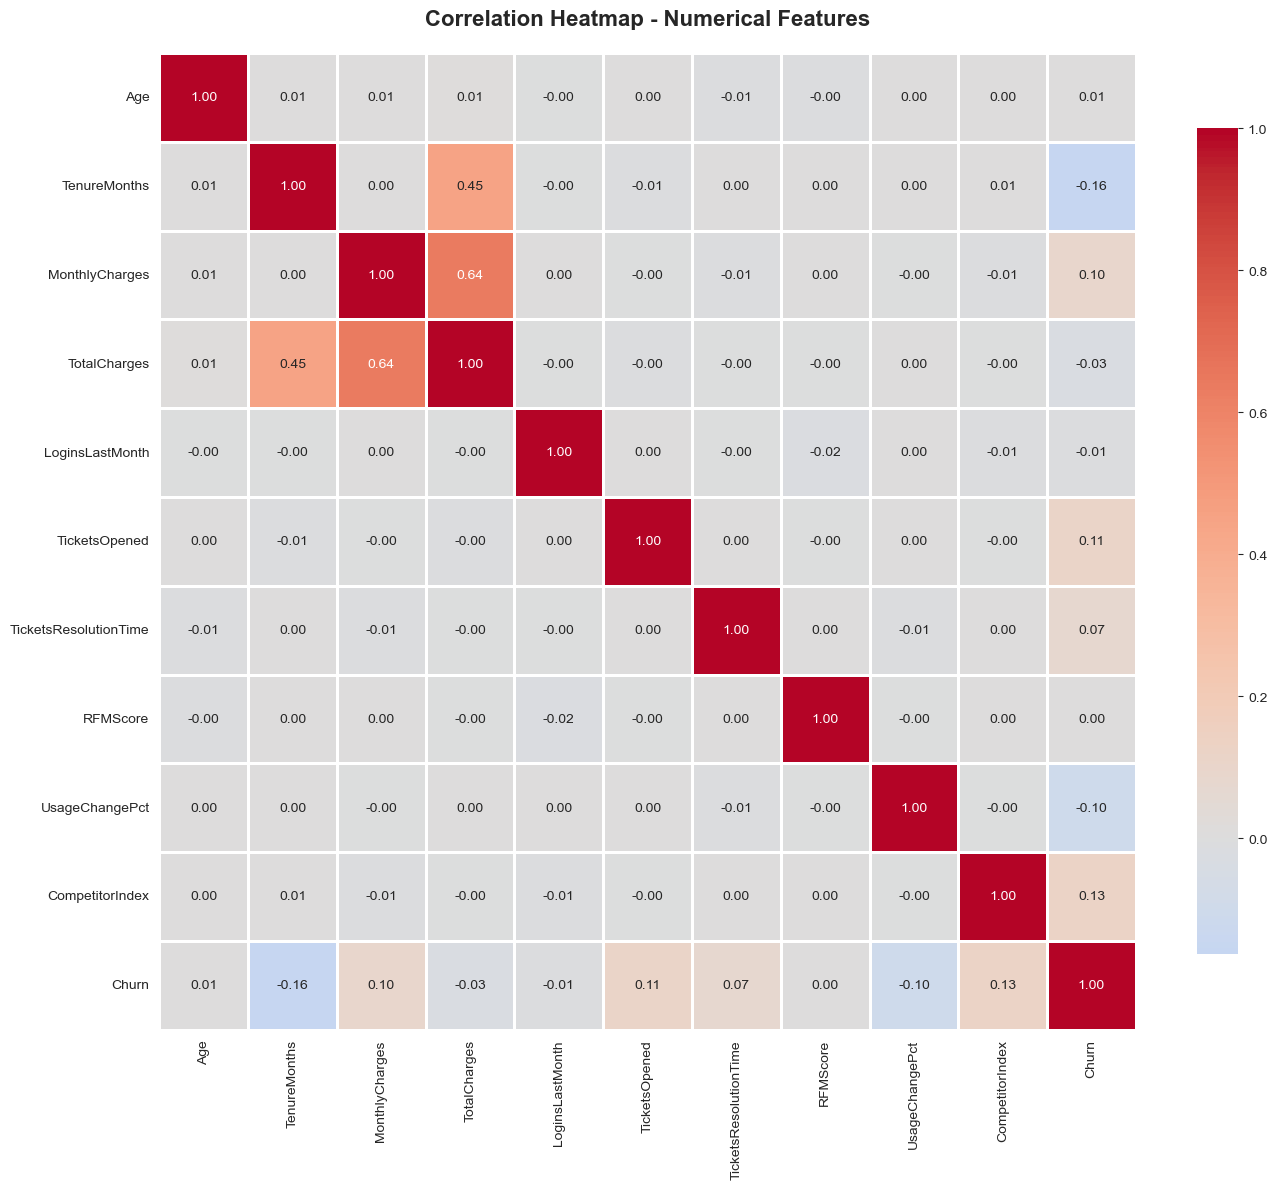

In [25]:
# Visualizing correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Categorical Features Analysis:

We analyze the distribution of categorical variables and their relationship with customer churn.

In [26]:
# Frequency distribution for categorical features
print("Categorical Features - Unique Value Counts:")
print("="*80)

cat_summary = []
for col in categorical_cols:
    unique_count = df[col].nunique()
    most_common = df[col].mode()[0] if len(df[col].mode()) > 0 else 'N/A'
    most_common_pct = (df[col].value_counts().iloc[0] / len(df)) * 100 if unique_count > 0 else 0
    
    cat_summary.append({
        'Feature': col,
        'Unique_Values': unique_count,
        'Most_Common': most_common,
        'Most_Common_Pct': most_common_pct
    })

cat_summary_df = pd.DataFrame(cat_summary)
print(cat_summary_df.to_string(index=False))

Categorical Features - Unique Value Counts:
                 Feature  Unique_Values Most_Common  Most_Common_Pct
                  Gender              8           0           12.748
              IncomeTier              6         low           24.804
                  Region              5       South           20.150
               Education              5     Diploma           40.006
          ContractLength              5         M2M           20.182
           PaymentMethod              7 Credit Card           14.500
                PlanType              7     Premium           16.870
              DeviceType              9      Mobile           47.734
        ChannelPreferred              9         App           31.852
         CustomerSegment              5      Bronze           34.628
                 AutoPay              8          No           29.190
               Paperless              6          No           35.092
              FamilyPlan              3          No        

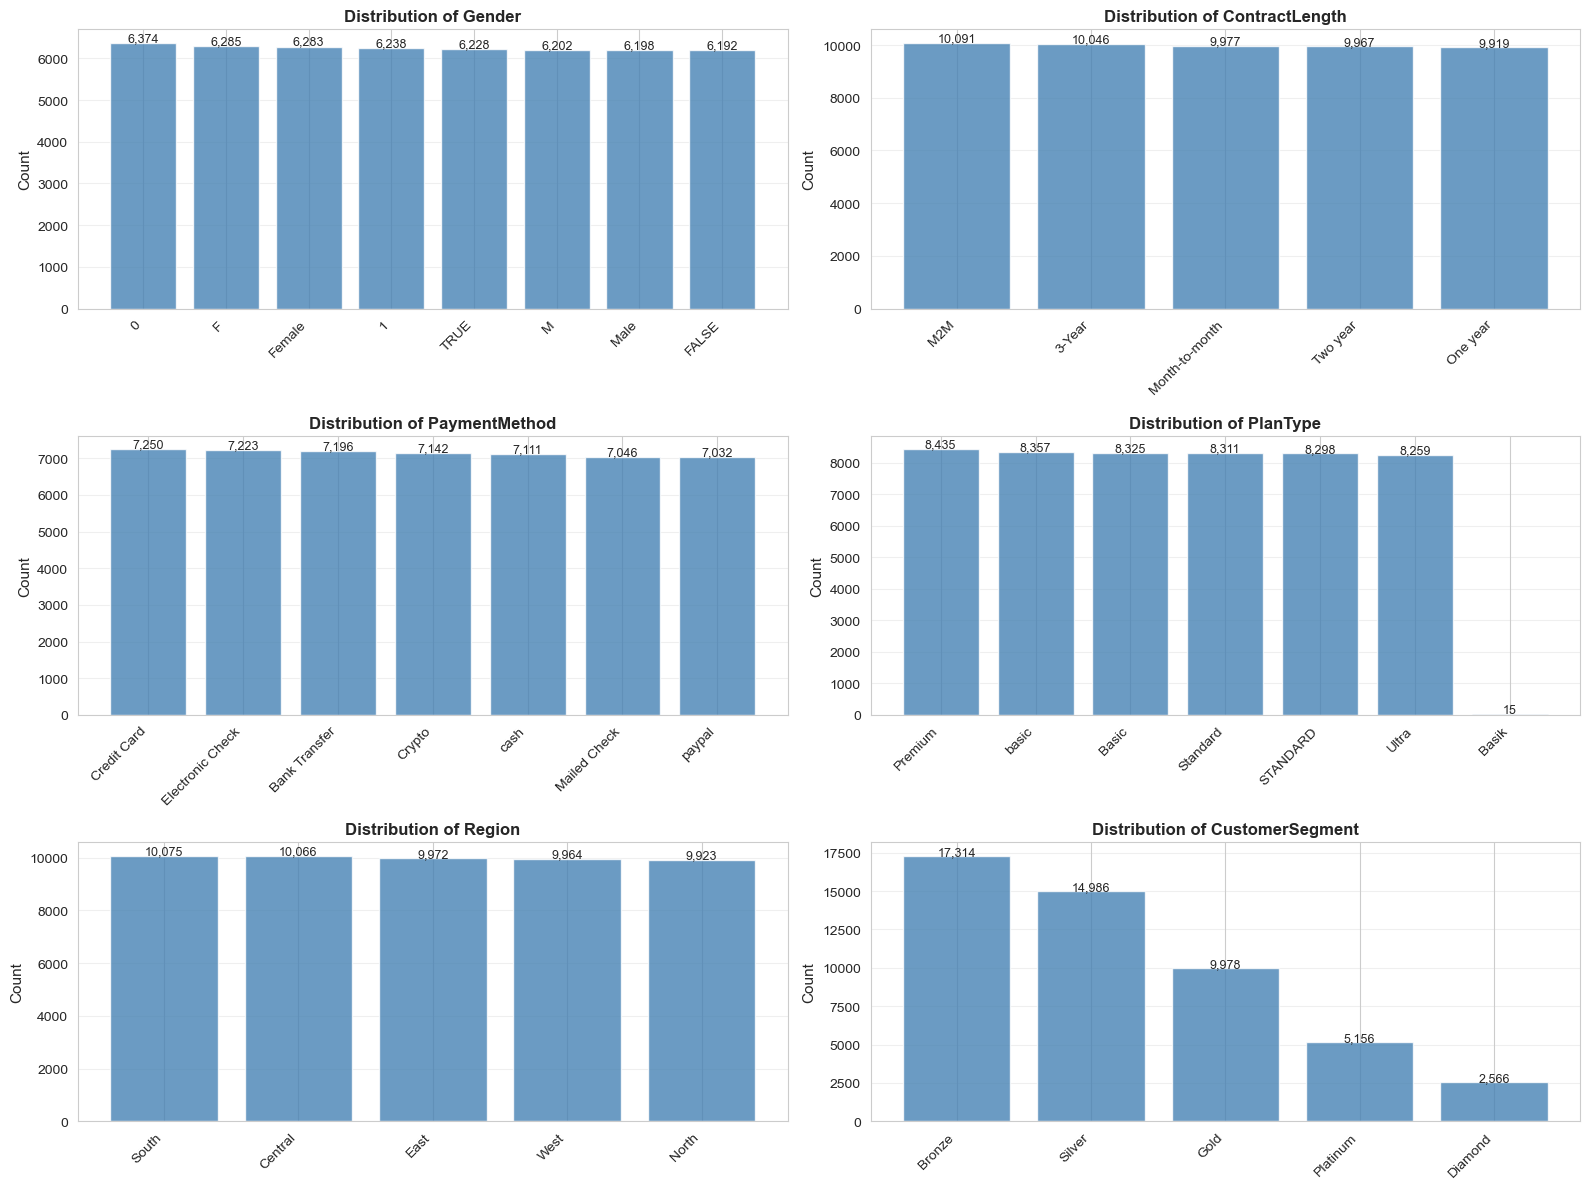

In [27]:
# Visualizing distribution of important categorical features
important_categorical = ['Gender', 'ContractLength', 'PaymentMethod', 'PlanType', 'Region', 'CustomerSegment']

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(important_categorical):
    if col in df.columns:
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue', alpha=0.8)
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_ylabel('Count', fontsize=11)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Data Quality Issues in Categorical Variables:

Clearly we can identify inconsistencies in categorical variables that needs to be solved during data preparation.


In [29]:
# Checking for inconsistencies in categorical variables
print("Data Quality Issues - Inconsistent Values:")
print("="*80)

issues_found = []

for col in categorical_cols:
    unique_vals = df[col].unique()
    
    # Checking for mixed case or similar values
    if len(unique_vals) > 0:
        unique_vals_str = [str(v).lower() for v in unique_vals if pd.notna(v)]
        unique_lower = set(unique_vals_str)
        
        if len(unique_lower) < len([v for v in unique_vals if pd.notna(v)]):
            issues_found.append({
                'Feature': col,
                'Unique_Values': len(unique_vals),
                'Sample_Values': str(list(unique_vals)[:10])
            })

if issues_found:
    issues_df = pd.DataFrame(issues_found)
    print(issues_df.to_string(index=False))
    print("\n These features require standardization during data preparation!")
else:
    print("No obvious inconsistencies detected.")


Data Quality Issues - Inconsistent Values:
         Feature  Unique_Values                                                                    Sample_Values
      IncomeTier              7                       ['Low', 'low', 'HIGH', 'Very High', 'High', 'Medium', nan]
        PlanType              7          ['basic', 'Standard', 'Ultra', 'Premium', 'Basic', 'STANDARD', 'Basik']
ChannelPreferred             10 ['Phone', 'Web', 'APP', 'App', 'Chat', 'In-Store', 'phone', 'web', 'Email', nan]
       Paperless              6                                          ['No', 'Yes', 'NO', 'yes', 'YES', 'no']
        DeviceOS              8       ['iOS', 'Android', 'Windows', 'Linux', 'Other', 'ios', 'macOS', 'ANDROID']

 These features require standardization during data preparation!


In [50]:
# Detailed view of problematic categorical variables
problematic_features = ['Gender', 'IncomeTier', 'ContractLength', 'PlanType', 'AutoPay', 'Paperless']

print("\nDetailed View of Potentially Problematic Features:")
print("="*80)

for col in problematic_features:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())
        print(f"Unique values: {df[col].nunique()}")



Detailed View of Potentially Problematic Features:

Gender:
Gender
0         6374
F         6285
Female    6283
1         6238
TRUE      6228
M         6202
Male      6198
FALSE     6192
Name: count, dtype: int64
Unique values: 8

IncomeTier:
IncomeTier
low          12402
Low           7546
Medium        7517
HIGH          7480
Very High     7439
High          7416
Name: count, dtype: int64
Unique values: 6

ContractLength:
ContractLength
M2M               10091
3-Year            10046
Month-to-month     9977
Two year           9967
One year           9919
Name: count, dtype: int64
Unique values: 5

PlanType:
PlanType
Premium     8435
basic       8357
Basic       8325
Standard    8311
STANDARD    8298
Ultra       8259
Basik         15
Name: count, dtype: int64
Unique values: 7

AutoPay:
AutoPay
No       14595
Yes      13913
1         5810
0         5442
TRUE      4002
FALSE     3684
N         1381
Y         1173
Name: count, dtype: int64
Unique values: 8

Paperless:
Paperless
No     1

In [30]:
# Churn rate by categorical features
print("Churn Rate Analysis by Categorical Features:")
print("="*80)

churn_by_category = []

for col in important_categorical:
    if col in df.columns:
        churn_rate_by_cat = df.groupby(col)['Churn'].agg(['sum', 'count', 'mean'])
        churn_rate_by_cat.columns = ['Churned', 'Total', 'Churn_Rate']
        churn_rate_by_cat['Churn_Rate_Pct'] = churn_rate_by_cat['Churn_Rate'] * 100
        churn_rate_by_cat = churn_rate_by_cat.sort_values('Churn_Rate_Pct', ascending=False)
        
        print(f"\n{col}:")
        print(churn_rate_by_cat)

Churn Rate Analysis by Categorical Features:

Gender:
        Churned  Total  Churn_Rate  Churn_Rate_Pct
Gender                                            
F          1677   6285       0.267          26.683
1          1650   6238       0.265          26.451
0          1681   6374       0.264          26.373
Male       1627   6198       0.263          26.250
TRUE       1603   6228       0.257          25.739
FALSE      1590   6192       0.257          25.678
M          1581   6202       0.255          25.492
Female     1591   6283       0.253          25.322

ContractLength:
                Churned  Total  Churn_Rate  Churn_Rate_Pct
ContractLength                                            
Month-to-month     3040   9977       0.305          30.470
M2M                2989  10091       0.296          29.620
One year           2348   9919       0.237          23.672
3-Year             2338  10046       0.233          23.273
Two year           2285   9967       0.229          22.926

Payme

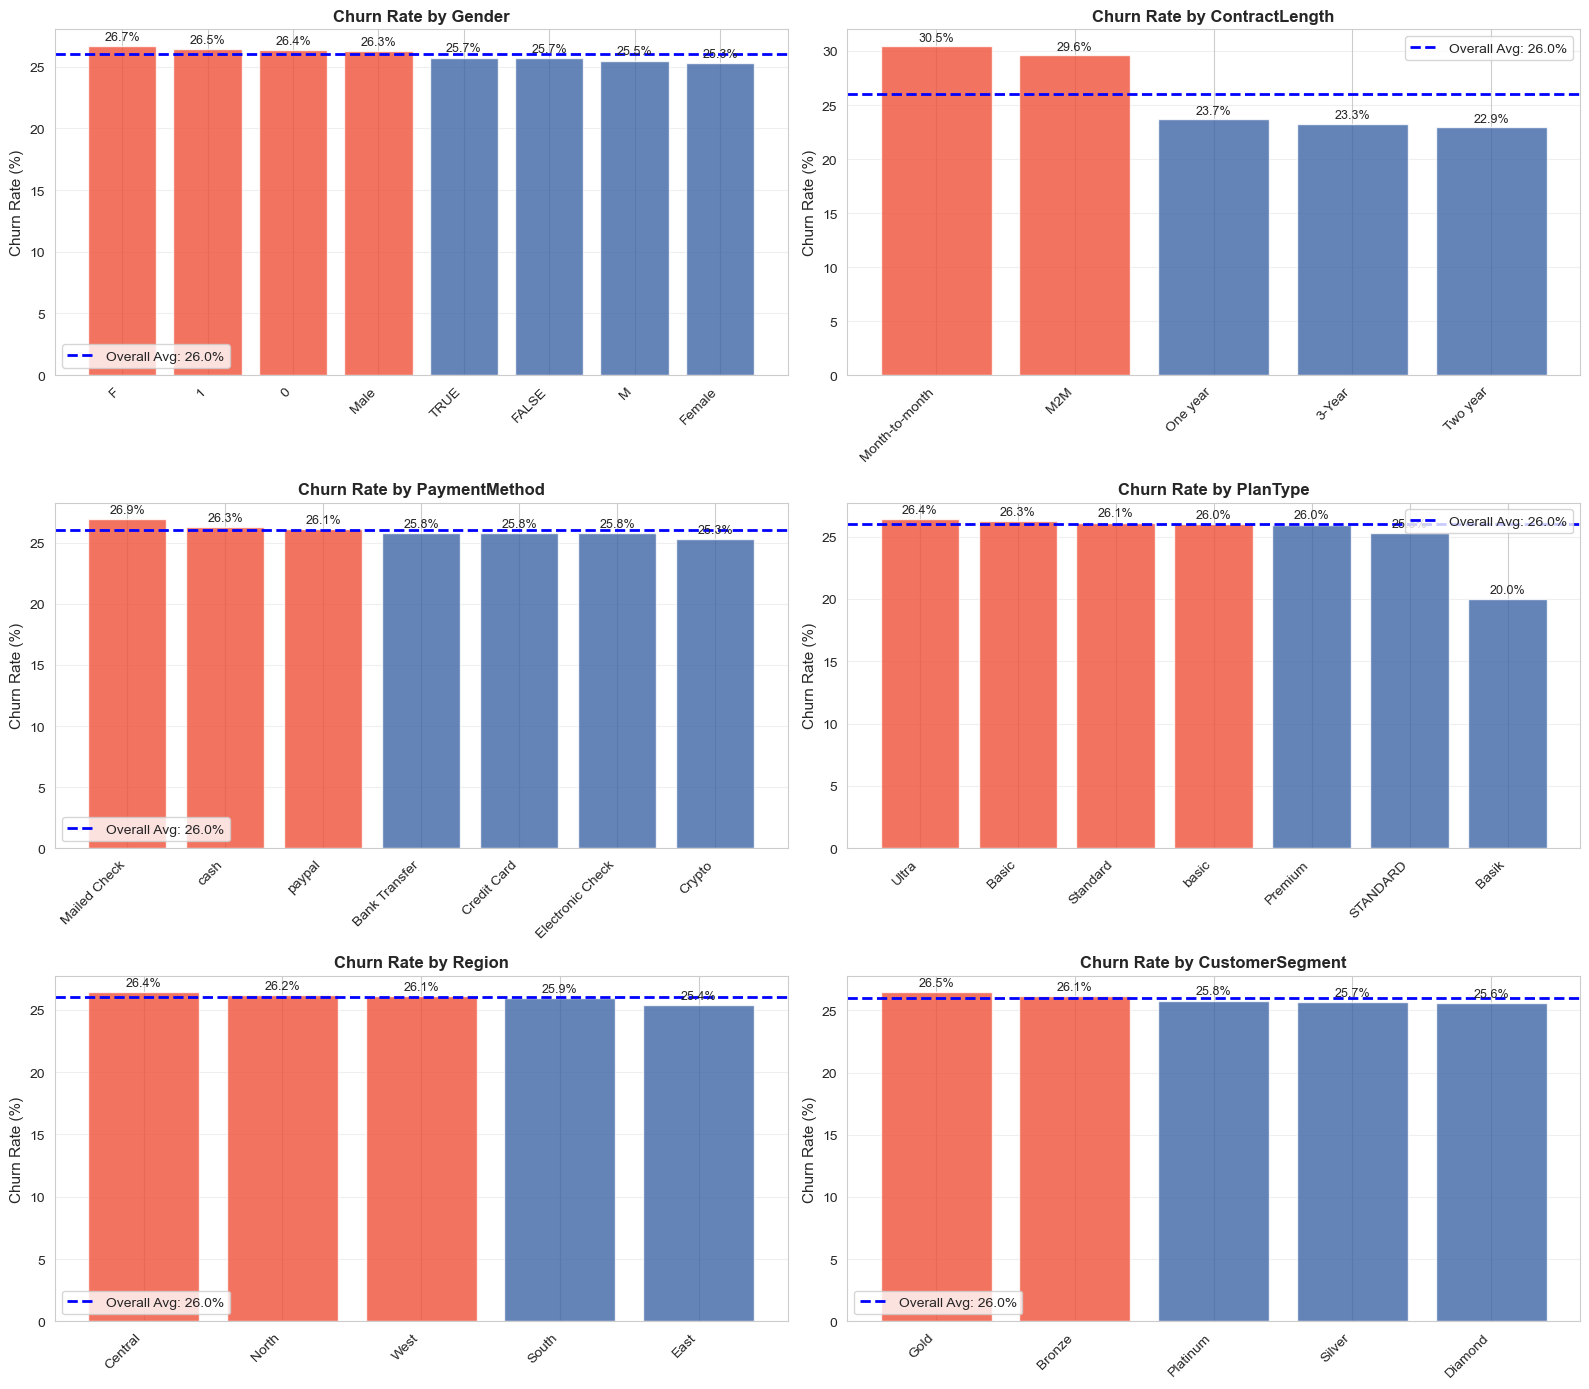

In [52]:
# Visualizing churn rate by categorical features
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, col in enumerate(important_categorical):
    if col in df.columns:
        churn_rate = df.groupby(col)['Churn'].mean() * 100
        churn_rate = churn_rate.sort_values(ascending=False)
        
        colors = [ '#F05039' if x > df['Churn'].mean()*100 else '#3D65A5' for x in churn_rate.values]
        
        axes[idx].bar(range(len(churn_rate)), churn_rate.values, color=colors, alpha=0.8)
        axes[idx].set_xticks(range(len(churn_rate)))
        axes[idx].set_xticklabels(churn_rate.index, rotation=45, ha='right')
        axes[idx].set_ylabel('Churn Rate (%)', fontsize=11)
        axes[idx].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
        axes[idx].axhline(y=df['Churn'].mean()*100, color='blue', linestyle='--', linewidth=2, label=f'Overall Avg: {df["Churn"].mean()*100:.1f}%')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Adding value labels
        for i, v in enumerate(churn_rate.values):
            axes[idx].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


Bivariate and Multivariate Analysis:

Now, we explore relationships between multiple variables to uncover patterns and insights.

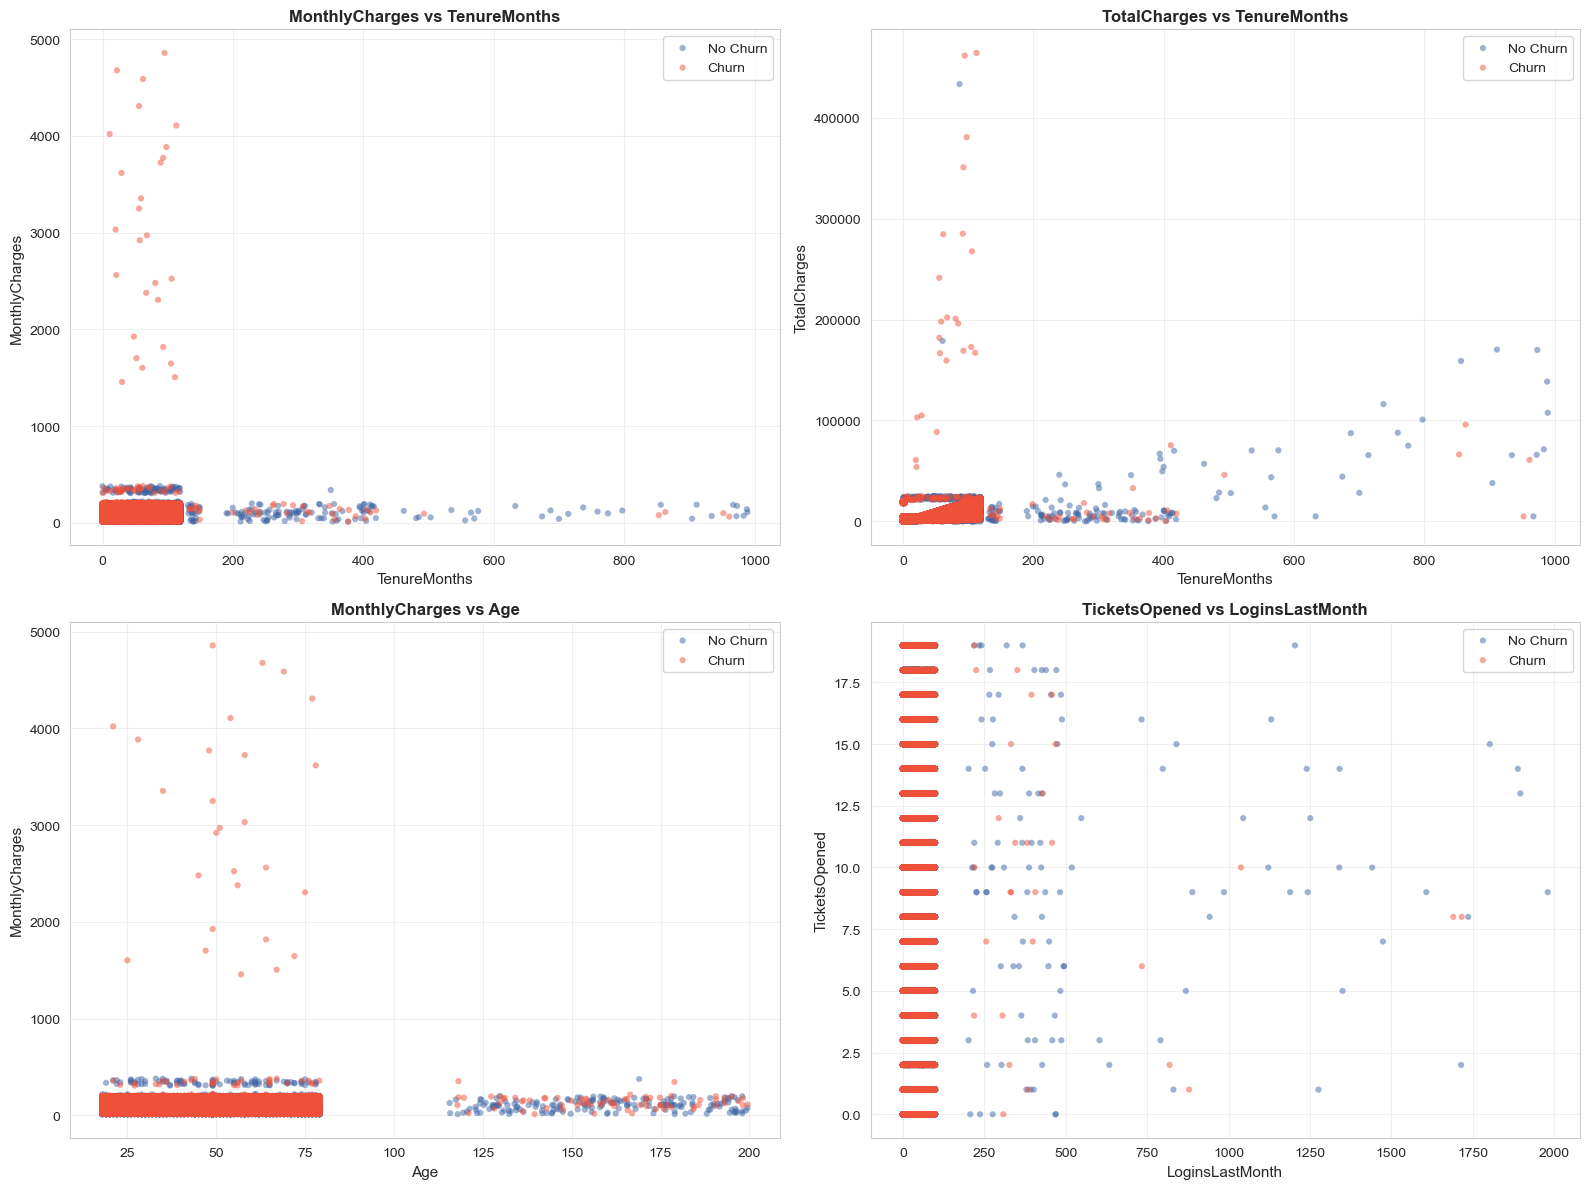

In [53]:
# Scatter plots: Numerical features colored by churn
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

scatter_pairs = [('TenureMonths', 'MonthlyCharges'),('TenureMonths', 'TotalCharges'),('Age', 'MonthlyCharges'),('LoginsLastMonth', 'TicketsOpened')]

for idx, (x_col, y_col) in enumerate(scatter_pairs):
    ax = axes[idx // 2, idx % 2]
    
    if x_col in df.columns and y_col in df.columns:
        # Plot non-churned customers
        no_churn = df[df['Churn'] == 0]
        churn = df[df['Churn'] == 1]
        
        ax.scatter(no_churn[x_col], no_churn[y_col], alpha=0.5, s=20, c='#3D65A5', label='No Churn', edgecolors='none')
        ax.scatter(churn[x_col], churn[y_col], alpha=0.5, s=20, c='#F05039', label='Churn', edgecolors='none')
        
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel(y_col, fontsize=11)
        ax.set_title(f'{y_col} vs {x_col}', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [31]:
# Summary statistics by churn status
print("Summary Comparison: Churned vs Non-Churned Customers")
print("="*80)

summary_cols = ['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'LoginsLastMonth', 'TicketsOpened']

for col in summary_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df.groupby('Churn')[col].describe()[['mean', '50%', 'std']])

Summary Comparison: Churned vs Non-Churned Customers

Age:
        mean    50%    std
Churn                     
0     49.041 49.000 18.639
1     49.344 49.000 18.914

TenureMonths:
        mean    50%    std
Churn                     
0     64.590 65.000 40.797
1     49.280 43.000 39.719

MonthlyCharges:
         mean     50%     std
Churn                        
0     102.058 105.165  52.865
1     121.438 111.880 149.762

TotalCharges:
          mean      50%       std
Churn                            
0     6562.987 4913.795  6154.053
1     6005.833 4826.360 11230.615

LoginsLastMonth:
        mean    50%    std
Churn                     
0     50.984 49.000 48.731
1     50.349 49.000 40.223

TicketsOpened:
        mean    50%   std
Churn                    
0      9.090  9.000 5.714
1     10.589 11.000 5.775


# Datacleaning_and_feature_engineering.ipynb

# 2. Data Preparation and Feature Engineering

#### Importing important Libraries to use

In [32]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import os

In [33]:
print(os.getcwd())

C:\Windows\System32\Srishti\IS6052\Final


#### Reading the data

In [37]:
df = pd.read_csv('C:\Windows\System32\Srishti\IS6052\Final\Omni_Churn_Data.csv')

#### Printing datatypes of each field of the dataset

In [38]:
df.dtypes

CustomerID                    int64
Age                         float64
Gender                       object
IncomeTier                   object
Region                       object
Education                    object
ContractLength               object
PaymentMethod                object
PlanType                     object
TenureMonths                float64
MonthlyCharges              float64
TotalCharges                float64
LoginsLastMonth             float64
TicketsOpened                 int64
TicketsResolutionTime       float64
RFMScore                      int64
UsageChangePct              float64
CompetitorIndex             float64
Churn                         int64
DeviceType                   object
ChannelPreferred             object
CustomerSegment              object
AutoPay                      object
Paperless                    object
FamilyPlan                   object
AddOnBundle                  object
ReferralSource               object
SupportChannelPreferred     

In [39]:
print("\nSummary missing values:")
df.isnull().sum()[df.isnull().sum() > 0]


Summary missing values:


Age                   25
IncomeTier           200
Education             20
MonthlyCharges        10
TotalCharges          10
DeviceType            24
ChannelPreferred      15
FamilyPlan             9
AddOnBundle           22
ComplaintCategory      3
DiscountType           2
PromoCodeUsed          3
dtype: int64

In [40]:
print(df.shape)

(50000, 35)


#### Creating a copy of dataset for cleaning

In [91]:
df_omni_churn_cleaned = df.copy()

In [42]:
df_omni_churn_cleaned.dtypes

CustomerID                    int64
Age                         float64
Gender                       object
IncomeTier                   object
Region                       object
Education                    object
ContractLength               object
PaymentMethod                object
PlanType                     object
TenureMonths                float64
MonthlyCharges              float64
TotalCharges                float64
LoginsLastMonth             float64
TicketsOpened                 int64
TicketsResolutionTime       float64
RFMScore                      int64
UsageChangePct              float64
CompetitorIndex             float64
Churn                         int64
DeviceType                   object
ChannelPreferred             object
CustomerSegment              object
AutoPay                      object
Paperless                    object
FamilyPlan                   object
AddOnBundle                  object
ReferralSource               object
SupportChannelPreferred     

#### A. Cleaning dataset

##### 1. Object fields: Use mode imputation (Excluding Columns with inconsistent values which is being handled in the next step)

In [92]:
categorical_churn_col = df_omni_churn_cleaned.select_dtypes(include=['object']).columns
for col in categorical_churn_col:
    if col not in ['Gender', 'IncomeTier', 'AutoPay', 'Paperless', 'ContractAutoRenew']:
        df_omni_churn_cleaned[col] = df_omni_churn_cleaned[col].fillna(df_omni_churn_cleaned[col].mode()[0])

In [93]:
categorical_churn_col

Index(['Gender', 'IncomeTier', 'Region', 'Education', 'ContractLength',
       'PaymentMethod', 'PlanType', 'DeviceType', 'ChannelPreferred',
       'CustomerSegment', 'AutoPay', 'Paperless', 'FamilyPlan', 'AddOnBundle',
       'ReferralSource', 'SupportChannelPreferred', 'ComplaintCategory',
       'DiscountType', 'ContractAutoRenew', 'DeviceOS', 'CityTier',
       'PromoCodeUsed', 'PaymentDelinquencyStatus'],
      dtype='object')

##### 2. Handling Inconsistent Categorical Entries (Standardisation)

In [94]:
# Gender: Standardize to Male/Female
gender_dict = {
    'M': 'Male', 'Male': 'Male', '1': 'Male', 'TRUE': 'Male',
    'F': 'Female', 'Female': 'Female', '0': 'Female', 'FALSE': 'Female'
}
df_omni_churn_cleaned['Gender'] = df_omni_churn_cleaned['Gender'].map(gender_dict).fillna(df_omni_churn_cleaned['Gender'].mode()[0])

In [95]:
gender_dict

{'M': 'Male',
 'Male': 'Male',
 '1': 'Male',
 'TRUE': 'Male',
 'F': 'Female',
 'Female': 'Female',
 '0': 'Female',
 'FALSE': 'Female'}

##### 3. Field - IncomeTier: Convert to Title Case and re-impute the NaN values

In [96]:
df_omni_churn_cleaned['IncomeTier'] = df_omni_churn_cleaned['IncomeTier'].str.title()
df_omni_churn_cleaned['IncomeTier'] = df_omni_churn_cleaned['IncomeTier'].fillna(df_omni_churn_cleaned['IncomeTier'].mode()[0])

In [97]:
df_omni_churn_cleaned['IncomeTier']

0              Low
1              Low
2              Low
3             High
4        Very High
           ...    
49995         High
49996          Low
49997          Low
49998          Low
49999          Low
Name: IncomeTier, Length: 50000, dtype: object

##### 4. Round LoginsLastMonth to the nearest integer

In [98]:
df_omni_churn_cleaned['LoginsLastMonth'] = df_omni_churn_cleaned['LoginsLastMonth'].round(0).astype(int)

##### 5. Standardization, Whitespacing and Special Character Handling

In [99]:
def standardize_categorical_column(series):
    # Remove non-alphanumeric characters (excluding spaces/hyphens needed for names)
    series = series.astype(str).str.replace(r'[^a-zA-Z0-9\s-]', '', regex=True)
    return series.str.title().str.strip() #Title case conversion

In [100]:
# Standardize ContractLength column
contract_dict = {'M2M': 'Month-To-Month', 'Month-To-Month': 'Month-To-Month',
                    'One Year': 'One Year', 'Two Year': 'Two Year', '3-Year': 'Three Year',
                    'Basik': 'Basic' }
df_omni_churn_cleaned['ContractLength'] = standardize_categorical_column(df_omni_churn_cleaned['ContractLength']).replace(contract_dict)

In [101]:
# Standardize PlanType Column
plantype_dict = {'Basik': 'Basic' }
df_omni_churn_cleaned['PlanType'] = standardize_categorical_column(df_omni_churn_cleaned['PlanType']).replace(plantype_dict)

In [102]:
# Standardize PaymentMethod, PlanType, ChannelPreferred
df_omni_churn_cleaned['PaymentMethod'] = standardize_categorical_column(df_omni_churn_cleaned['PaymentMethod'])
df_omni_churn_cleaned['PlanType'] = standardize_categorical_column(df_omni_churn_cleaned['PlanType'])
df_omni_churn_cleaned['ChannelPreferred'] = standardize_categorical_column(df_omni_churn_cleaned['ChannelPreferred'])

In [103]:
# Standardize DeviceType Column
devicetype_dict = {'M0bile': 'Mobile', '???' : 'Mobile', 'Featurephone': 'Mobile', 'M0Bile': 'Mobile',
                  'Smarttv': 'SmartTV'}
df_omni_churn_cleaned['DeviceType'] = standardize_categorical_column(df_omni_churn_cleaned['DeviceType']).replace(devicetype_dict)
df_omni_churn_cleaned.replace("", np.nan, inplace=True)
df_omni_churn_cleaned['DeviceType'] = standardize_categorical_column(df_omni_churn_cleaned['DeviceType'])
df_omni_churn_cleaned["DeviceType"] = df_omni_churn_cleaned["DeviceType"].fillna(df_omni_churn_cleaned["DeviceType"].mode()[0])

In [104]:
familyplan_mode = df_omni_churn_cleaned['FamilyPlan'].mode()[0] 
df_omni_churn_cleaned['FamilyPlan'] = df_omni_churn_cleaned['FamilyPlan'].fillna(familyplan_mode)

In [105]:
columns_to_clean = ['DeviceType', 'FamilyPlan']
for col in columns_to_clean:
    df_omni_churn_cleaned[col] = df_omni_churn_cleaned[col].astype(str).str.strip()
    df_omni_churn_cleaned.loc[df_omni_churn_cleaned[col] == '', col] = np.nan
    
    df_omni_churn_cleaned.loc[df_omni_churn_cleaned[col].str.lower() == 'nan', col] = np.nan # Replace the string 'nan' with the proper NaN marker

for col in columns_to_clean:
    # Check if there are now NaN values to fill
    missing_count = df_omni_churn_cleaned[col].isnull().sum() 
    
    if missing_count > 0:
        mode_value = df_omni_churn_cleaned[col].mode()[0] #Impute Resulting NaN Values with Mode and Calculate mode only on non-NaN values
        
        df_omni_churn_cleaned[col] = df_omni_churn_cleaned[col].fillna(mode_value) # Fill the NaN values

##### 6. Binary Columns (AutoPay, Paperless, ContractAutoRenew): Standardize to Yes/No

In [106]:
binary_dict = {'TRUE': 'Yes', '1': 'Yes', 'Yes': 'Yes', 'Y': 'Yes',
              'FALSE': 'No', '0': 'No', 'No': 'No', 'N': 'No', 'no': 'No', 'yes': 'Yes', 'NO': 'No', 'YES': 'Yes'}


df_omni_churn_cleaned['AutoPay'] = df_omni_churn_cleaned['AutoPay'].map(binary_dict)
df_omni_churn_cleaned['Paperless'] = df_omni_churn_cleaned['Paperless'].map(binary_dict)
df_omni_churn_cleaned['ContractAutoRenew'] = df_omni_churn_cleaned['ContractAutoRenew'].map(binary_dict).fillna('No') # Filling Unknown/NaN with 'No'
df_omni_churn_cleaned['FamilyPlan'] = df_omni_churn_cleaned['FamilyPlan'].fillna(df_omni_churn_cleaned['FamilyPlan'].mode()[0]) # Fill remaining NaN

##### 7. Dealing with negative values for TotalCharges

In [107]:
# Identify the median of all NON-NEGATIVE TotalCharges
positive_charges_median = df_omni_churn_cleaned.loc[df_omni_churn_cleaned['TotalCharges'] >= 0, 'TotalCharges'].median()

# Apply the correction: Replace negative TotalCharges with the positive median
df_omni_churn_cleaned.loc[df_omni_churn_cleaned['TotalCharges'] < 0, 'TotalCharges'] = positive_charges_median

##### 8. Numerical fields missing values.

In [110]:
numerical_cols = ['Age', 'MonthlyCharges', 'TotalCharges']
for col in numerical_cols:
    df_omni_churn_cleaned[col] = df_omni_churn_cleaned[col].fillna(df_omni_churn_cleaned[col].median())

In [108]:
print(df_omni_churn_cleaned.head())

   CustomerID    Age  Gender IncomeTier Region  Education  ContractLength  \
0           1 56.000    Male        Low   East    Diploma        One Year   
1           2 69.000  Female        Low  North    Diploma  Month-To-Month   
2           3 46.000    Male        Low  North    Diploma        Two Year   
3           4 32.000  Female       High   East    Diploma      Three Year   
4           5 60.000    Male  Very High   East  Bachelors        One Year   

      PaymentMethod  PlanType  TenureMonths  MonthlyCharges  TotalCharges  \
0  Electronic Check     Basic        67.000          87.550      5865.850   
1            Paypal  Standard        97.000         131.960     23765.743   
2            Paypal     Ultra        22.000          79.950      1758.900   
3  Electronic Check   Premium        65.000         105.840      6879.600   
4            Paypal     Ultra        27.000         134.060      3619.620   

   LoginsLastMonth  TicketsOpened  TicketsResolutionTime  RFMScore  \
0   

In [111]:
print("\nMissing values in cleaned dataset:")
df_omni_churn_cleaned.sum()[df_omni_churn_cleaned.isnull().sum() > 0]


Missing values in cleaned dataset:


Series([], dtype: object)

In [112]:
df_omni_churn_cleaned.dtypes

CustomerID                    int64
Age                         float64
Gender                       object
IncomeTier                   object
Region                       object
Education                    object
ContractLength               object
PaymentMethod                object
PlanType                     object
TenureMonths                float64
MonthlyCharges              float64
TotalCharges                float64
LoginsLastMonth               int64
TicketsOpened                 int64
TicketsResolutionTime       float64
RFMScore                      int64
UsageChangePct              float64
CompetitorIndex             float64
Churn                         int64
DeviceType                   object
ChannelPreferred             object
CustomerSegment              object
AutoPay                      object
Paperless                    object
FamilyPlan                   object
AddOnBundle                  object
ReferralSource               object
SupportChannelPreferred     

In [113]:
print(df_omni_churn_cleaned.shape)

(50000, 35)


In [63]:
df_omni_churn_cleaned.to_csv("Omni_Churn_Data_Cleaned.csv", index = False)

#### B. Feature Engineering

##### 1. Derived Metrics

###### i. Avg Monthly Charge = Total Charges / Tenure Months

In [114]:
df_omni_churn_cleaned['AvgMonthlyCharge'] = df_omni_churn_cleaned['TotalCharges'] / df_omni_churn_cleaned['TenureMonths']

# In case of division by zero (TenureMonths=0) or inf/-inf by setting to 0 or imputing NaN to 0:
df_omni_churn_cleaned['AvgMonthlyCharge'] = df_omni_churn_cleaned['AvgMonthlyCharge'].replace([float('inf'), -float('inf')], 0).fillna(0)

In [115]:
df_omni_churn_cleaned['AvgMonthlyCharge']

0        87.550
1       245.008
2        79.950
3       105.840
4       134.060
          ...  
49995   178.600
49996    38.180
49997   136.810
49998   168.400
49999   272.989
Name: AvgMonthlyCharge, Length: 50000, dtype: float64

###### ii. Logins Per Month = Logins Last Month / Tenure Months

In [116]:
df_omni_churn_cleaned['LoginsPerMonth'] = df_omni_churn_cleaned['LoginsLastMonth'] / df_omni_churn_cleaned['TenureMonths']
df_omni_churn_cleaned['LoginsPerMonth'] = df_omni_churn_cleaned['LoginsPerMonth'].replace([float('inf'), -float('inf')], 0).fillna(0)

In [117]:
df_omni_churn_cleaned['LoginsPerMonth']

0       0.313
1       0.454
2       3.818
3       0.523
4       1.370
         ... 
49995   0.923
49996   1.000
49997   0.221
49998   0.988
49999   3.278
Name: LoginsPerMonth, Length: 50000, dtype: float64

###### iii. Support ticket intensity = TicketsOpened / TenureMonths

In [118]:
df_omni_churn_cleaned['SupportTicketIntensity'] = np.divide(
    df_omni_churn_cleaned['TicketsOpened'], 
    df_omni_churn_cleaned['TenureMonths'], 

    out=np.zeros_like(df_omni_churn_cleaned['TicketsOpened'], dtype=float),  # Handling division by zero (where TenureMonths=0) by setting the result to 0.0
    where=df_omni_churn_cleaned['TenureMonths'] != 0 
)

In [119]:
df_omni_churn_cleaned['SupportTicketIntensity'] 

0       0.090
1       0.062
2       0.136
3       0.015
4       0.556
         ... 
49995   0.103
49996   3.000
49997   0.221
49998   0.106
49999   0.778
Name: SupportTicketIntensity, Length: 50000, dtype: float64

###### iv. ServiceRedFlag = Feature Interaction/Transformation

In [120]:
mean_resolution_time = df_omni_churn_cleaned['TicketsResolutionTime'].mean()
std_resolution_time = df_omni_churn_cleaned['TicketsResolutionTime'].std()
high_resolution_time_threshold = mean_resolution_time + std_resolution_time

condition = (
    (df_omni_churn_cleaned['TicketsOpened'] > 0) &  
    (df_omni_churn_cleaned['TicketsResolutionTime'] > high_resolution_time_threshold)
)

df_omni_churn_cleaned['ServiceRedFlag'] = np.where(
    condition, 
    1,  # Value if condition is True
    0   # Value if condition is False
)

In [121]:
df_omni_churn_cleaned['ServiceRedFlag']

0        0
1        0
2        0
3        0
4        0
        ..
49995    0
49996    0
49997    0
49998    0
49999    0
Name: ServiceRedFlag, Length: 50000, dtype: int64

###### v. TenureGroup (Categorical Transformation)

In [122]:
bins = [0, 12, 36, np.inf]
labels = ['Short(0-12m)', 'Medium(13-36m)', 'Long(37m+)']

df_omni_churn_cleaned['TenureGroup'] = pd.cut(
    df_omni_churn_cleaned['TenureMonths'], 
    bins=bins, 
    labels=labels, 
    right=True, 
    include_lowest=True
)

In [123]:
df_omni_churn_cleaned['TenureGroup']

0            Long(37m+)
1            Long(37m+)
2        Medium(13-36m)
3            Long(37m+)
4        Medium(13-36m)
              ...      
49995        Long(37m+)
49996      Short(0-12m)
49997        Long(37m+)
49998        Long(37m+)
49999    Medium(13-36m)
Name: TenureGroup, Length: 50000, dtype: category
Categories (3, object): ['Short(0-12m)' < 'Medium(13-36m)' < 'Long(37m+)']

In [124]:
df_omni_churn_cleaned

,CustomerID,Age,Gender,IncomeTier,Region,Education,ContractLength,PaymentMethod,PlanType,TenureMonths,MonthlyCharges,TotalCharges,LoginsLastMonth,TicketsOpened,TicketsResolutionTime,RFMScore,UsageChangePct,CompetitorIndex,Churn,DeviceType,ChannelPreferred,CustomerSegment,AutoPay,Paperless,FamilyPlan,AddOnBundle,ReferralSource,SupportChannelPreferred,ComplaintCategory,DiscountType,ContractAutoRenew,DeviceOS,CityTier,PromoCodeUsed,PaymentDelinquencyStatus,AvgMonthlyCharge,LoginsPerMonth,SupportTicketIntensity,ServiceRedFlag,TenureGroup
0,1,56.000,Male,Low,East,Diploma,One Year,Electronic Check,Basic,67.000,87.550,5865.850,21,6,11.986,14,-0.264,0.207,0,Desktop,Phone,Bronze,Yes,No,No,Movies,Unknown,Social,Technical,Loyalty,No,iOS,Tier-2,SUMMER,Current,87.550,0.313,0.090,0,Long(37m+)
1,2,69.000,Female,Low,North,Diploma,Month-To-Month,Paypal,Standard,97.000,131.960,23765.743,44,6,46.033,7,-0.146,0.618,0,Mobile,Web,Silver,No,Yes,No,Sports,Search,Phone,Technical,Loyalty,Yes,iOS,Tier-3,WELCOME,Current,245.008,0.454,0.062,0,Long(37m+)
2,3,46.000,Male,Low,North,Diploma,Two Year,Paypal,Ultra,22.000,79.950,1758.900,84,3,39.915,4,0.309,0.149,0,Mobile,App,Gold,Yes,Yes,Yes,Movies,Friend,Phone,Technical,Loyalty,No,Android,Tier-3,SUMMER,Current,79.950,3.818,0.136,0,Medium(13-36m)
3,4,32.000,Female,High,East,Diploma,Three Year,Electronic Check,Premium,65.000,105.840,6879.600,34,1,57.600,5,-0.985,0.986,1,Mobile,App,Silver,Yes,No,No,Movies,Event,Phone,Technical,Promo,No,Android,Tier-2,CYBER,Current,105.840,0.523,0.015,0,Long(37m+)
4,5,60.000,Male,Very High,East,Bachelors,One Year,Paypal,Ultra,27.000,134.060,3619.620,37,15,38.541,13,-0.476,0.106,0,Mobile,Chat,Bronze,Yes,Yes,No,WorkFromHome,Friend,Phone,Technical,Loyalty,Yes,Android,Tier-2,SUMMER,60+,134.060,1.370,0.556,0,Medium(13-36m)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,54.000,Female,High,North,Diploma,Month-To-Month,Bank Transfer,Standard,78.000,178.600,13930.800,72,8,24.832,10,-0.817,0.871,0,Mobile,Phone,Platinum,Yes,Yes,Yes,Kids,Affiliate,Phone,Technical,Intro,No,Android,Tier-2,SUMMER,Current,178.600,0.923,0.103,0,Long(37m+)
49996,49997,21.000,Male,Low,Central,Bachelors,Three Year,Electronic Check,Premium,6.000,38.180,229.080,6,18,35.111,4,-0.977,0.881,1,Smarttv,Web,Silver,Yes,Yes,Yes,Music,Friend,Email,Technical,Loyalty,No,Windows,Tier-3,SUMMER,Current,38.180,1.000,3.000,0,Short(0-12m)
49997,49998,47.000,Male,Low,Central,Diploma,Month-To-Month,Bank Transfer,Standard,77.000,136.810,10534.370,17,17,31.390,4,0.819,0.863,1,Desktop,Phone,Bronze,No,Yes,No,Movies,Event,Community,Technical,Loyalty,Yes,iOS,Tier-2,SUMMER,Current,136.810,0.221,0.221,0,Long(37m+)
49998,49999,37.000,Female,Low,West,Bachelors,One Year,Cash,Premium,85.000,168.400,14314.000,84,9,54.281,5,0.422,0.989,1,Console,App,Silver,Yes,No,Yes,Movies,Friend,Email,Outage,Bundle,No,Windows,Tier-1,SUMMER,Current,168.400,0.988,0.106,0,Long(37m+)


In [125]:
df_omni_churn_cleaned.shape

(50000, 40)

In [75]:
df_omni_churn_cleaned.to_csv("Omni_Churn_Data_Featured.csv", index = False)

##### 2. Encoding Categorical and Binary Variables

###### i. Binary Encoding: Standardizing to 1 and 0

In [126]:
binary_columns = ['Gender', 'AutoPay', 'Paperless', 'FamilyPlan', 'ContractAutoRenew']

binary_dict = {'male': 1, 'female': 0, 'yes': 1, 'no': 0} 

for col in binary_columns:
    cleaned = df_omni_churn_cleaned[col].astype(str).str.strip().str.lower() #Clean the data: Removing whitespace and convert to lowercase
    
    mapped = cleaned.map(binary_dict) #male = 1 and female = 0
    
    filled = mapped.fillna(0) #Fill NaN which are unmapped with 0 and fillna(0) as a safer option against any values that are still not mapped 
     
    df_omni_churn_cleaned[col] = filled.astype(int) #Converting to integer

In [128]:
df_omni_churn_cleaned[['Gender', 'AutoPay', 'Paperless', 'FamilyPlan', 'ContractAutoRenew']]

,Gender,AutoPay,Paperless,FamilyPlan,ContractAutoRenew
0,1,1,0,0,0
1,0,0,1,0,1
2,1,1,1,1,0
3,0,1,0,0,0
4,1,1,1,0,1
...,...,...,...,...,...
49995,0,1,1,1,0
49996,1,1,1,1,0
49997,1,0,1,0,1
49998,0,1,0,1,0


###### ii. Ordinal Encoding: Providing a rank according to categories

In [130]:
income_tier_dict = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}

customer_segment_dict = {
    'Bronze': 1,
    'Silver': 2,
    'Gold': 3,
    'Platinum': 4,
    'Diamond': 5
}

education_dict = {
    'High School': 1,
    'Diploma': 2,
    'Bachelors': 3,
    'Masters': 4,
    'PhD': 5
}

plantype_dict = {
    'Basic': 1,
    'Standard': 2,
    'Premium': 3,
    'Ultra': 4,
}

citytier_dict = {
    'Tier-4': 1,
    'Tier-3': 2,
    'Tier-2': 3,
    'Tier-1': 4
}

# Ordinal Encoding for TenureGroup (new feature) - Point - B.v)
tenure_group_dict = {
    'Short(0-12m)': 1,
    'Medium(13-36m)': 2,
    'Long(37m+)': 3
}

# Mapping to the respective columns
df_omni_churn_cleaned['IncomeTier_Encoded'] = df_omni_churn_cleaned['IncomeTier'].map(income_tier_dict)
df_omni_churn_cleaned['CustomerSegment_Encoded'] = df_omni_churn_cleaned['CustomerSegment'].map(customer_segment_dict)
df_omni_churn_cleaned['Education_Encoded'] = df_omni_churn_cleaned['Education'].map(education_dict)
df_omni_churn_cleaned['PlanType_Encoded'] = df_omni_churn_cleaned['PlanType'].map(plantype_dict)
df_omni_churn_cleaned['CityTier_Encoded'] = df_omni_churn_cleaned['CityTier'].map(citytier_dict)
df_omni_churn_cleaned['TenureGroup_Encoded'] = df_omni_churn_cleaned['TenureGroup'].map(tenure_group_dict)

# Drop the original string columns after encoding
df_omni_churn_cleaned = df_omni_churn_cleaned.drop(columns=['IncomeTier', 'CustomerSegment','Education','PlanType','CityTier','TenureGroup'])
print("Ordinal Encoded Features Head:")
print(df_omni_churn_cleaned[['IncomeTier_Encoded', 'CustomerSegment_Encoded','Education_Encoded','PlanType_Encoded','CityTier_Encoded']].head().to_markdown(index=False))

Ordinal Encoded Features Head:
|   IncomeTier_Encoded |   CustomerSegment_Encoded |   Education_Encoded |   PlanType_Encoded |   CityTier_Encoded |
|---------------------:|--------------------------:|--------------------:|-------------------:|-------------------:|
|                    1 |                         1 |                   2 |                  1 |                  3 |
|                    1 |                         2 |                   2 |                  2 |                  2 |
|                    1 |                         3 |                   2 |                  4 |                  2 |
|                    3 |                         2 |                   2 |                  3 |                  3 |
|                    4 |                         1 |                   3 |                  4 |                  3 |


###### iii. One-Hot Encoding for Nominal data

In [131]:
nominal_columns = ['Region', 'PaymentMethod', 'DeviceType', 'ChannelPreferred', 'DiscountType']

# Apply One-Hot Encoding
df_omni_churn_cleaned = pd.get_dummies(df_omni_churn_cleaned, columns=nominal_columns, drop_first=True)

In [135]:
df_omni_churn_cleaned

,CustomerID,Age,Gender,ContractLength,TenureMonths,MonthlyCharges,TotalCharges,LoginsLastMonth,TicketsOpened,TicketsResolutionTime,RFMScore,UsageChangePct,CompetitorIndex,Churn,AutoPay,Paperless,FamilyPlan,AddOnBundle,ReferralSource,SupportChannelPreferred,ComplaintCategory,ContractAutoRenew,DeviceOS,PromoCodeUsed,PaymentDelinquencyStatus,AvgMonthlyCharge,LoginsPerMonth,SupportTicketIntensity,ServiceRedFlag,IncomeTier_Encoded,CustomerSegment_Encoded,Education_Encoded,PlanType_Encoded,CityTier_Encoded,TenureGroup_Encoded,Region_East,Region_North,Region_South,Region_West,PaymentMethod_Cash,PaymentMethod_Credit Card,PaymentMethod_Crypto,PaymentMethod_Electronic Check,PaymentMethod_Mailed Check,PaymentMethod_Paypal,DeviceType_Desktop,DeviceType_Mobile,DeviceType_Smarttv,DeviceType_Tablet,ChannelPreferred_Chat,ChannelPreferred_Email,ChannelPreferred_In-Store,ChannelPreferred_Phone,ChannelPreferred_Web,DiscountType_Employee,DiscountType_Intro,DiscountType_Loyalty,DiscountType_Promo,DiscountType_Student
0,1,56.000,1,One Year,67.000,87.550,5865.850,21,6,11.986,14,-0.264,0.207,0,1,0,0,Movies,Unknown,Social,Technical,0,iOS,SUMMER,Current,87.550,0.313,0.090,0,1,1,2,1,3,3,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False
1,2,69.000,0,Month-To-Month,97.000,131.960,23765.743,44,6,46.033,7,-0.146,0.618,0,0,1,0,Sports,Search,Phone,Technical,1,iOS,WELCOME,Current,245.008,0.454,0.062,0,1,2,2,2,2,3,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,True,False,False
2,3,46.000,1,Two Year,22.000,79.950,1758.900,84,3,39.915,4,0.309,0.149,0,1,1,1,Movies,Friend,Phone,Technical,0,Android,SUMMER,Current,79.950,3.818,0.136,0,1,3,2,4,2,2,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False
3,4,32.000,0,Three Year,65.000,105.840,6879.600,34,1,57.600,5,-0.985,0.986,1,1,0,0,Movies,Event,Phone,Technical,0,Android,CYBER,Current,105.840,0.523,0.015,0,3,2,2,3,3,3,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
4,5,60.000,1,One Year,27.000,134.060,3619.620,37,15,38.541,13,-0.476,0.106,0,1,1,0,WorkFromHome,Friend,Phone,Technical,1,Android,SUMMER,60+,134.060,1.370,0.556,0,4,1,3,4,3,2,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,54.000,0,Month-To-Month,78.000,178.600,13930.800,72,8,24.832,10,-0.817,0.871,0,1,1,1,Kids,Affiliate,Phone,Technical,0,Android,SUMMER,Current,178.600,0.923,0.103,0,3,4,2,2,3,3,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False
49996,49997,21.000,1,Three Year,6.000,38.180,229.080,6,18,35.111,4,-0.977,0.881,1,1,1,1,Music,Friend,Email,Technical,0,Windows,SUMMER,Current,38.180,1.000,3.000,0,1,2,3,3,2,1,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
49997,49998,47.000,1,Month-To-Month,77.000,136.810,10534.370,17,17,31.390,4,0.819,0.863,1,0,1,0,Movies,Event,Community,Technical,1,iOS,SUMMER,Current,136.810,0.221,0.221,0,1,1,2,2,3,3,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False
49998,49999,37.000,0,One Year,85.000,168.400,14314.000,84,9,54.281,5,0.422,0.989,1,1,0,1,Movies,Friend,Email,Outage,0,Windows,SUMMER,Current,168.400,0.988,0.106,0,1,2,3,3,4,3,False,False,False,True,True,False,False,False,False,False

In [134]:
df_omni_churn_cleaned.shape

(50000, 59)

In [82]:
df_omni_churn_cleaned.to_excel("df_omni_churn_cleaned.xlsx", index = False)

#### C. Outlier Handling

##### TotalCharges, TicketResolutionTime and UsageChangePct have distributed minimum and maximum values. Hence, capping/winsorisation will help in handling those outliers using IQR method

In [136]:
def cap_outliers_iqr(df_omni_churn_cleaned, column, lower_limit_zero=False):
    
    Q1 = df_omni_churn_cleaned[column].quantile(0.25)
    Q3 = df_omni_churn_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if lower_limit_zero and lower_bound < 0:  # Check for non-negative constraint
        lower_bound = 0

    outliers_low = df_omni_churn_cleaned[df_omni_churn_cleaned[column] < lower_bound].shape[0]
    outliers_high = df_omni_churn_cleaned[df_omni_churn_cleaned[column] > upper_bound].shape[0]

    df_omni_churn_cleaned[column] = np.where(df_omni_churn_cleaned[column] > upper_bound, upper_bound, df_omni_churn_cleaned[column]) # Apply capping
    df_omni_churn_cleaned[column] = np.where(df_omni_churn_cleaned[column] < lower_bound, lower_bound, df_omni_churn_cleaned[column])
    
    return df_omni_churn_cleaned

# Define the columns and their required non-negative constraint
# True = cannot be negative (TotalCharges, TicketsResolutionTime)
# False = can be negative (UsageChangePct)

columns_to_cap = [
    ('TotalCharges', True),
    ('TicketsResolutionTime', True),
    ('UsageChangePct', False)
]

for column, non_negative in columns_to_cap:
    df_omni_churn_cleaned = cap_outliers_iqr(df_omni_churn_cleaned, column, lower_limit_zero=non_negative) # Apply capping to all three columns sequentially

capped_columns = ['TotalCharges', 'TicketsResolutionTime', 'UsageChangePct']

print("New min and max values after winsorisation")

for col in capped_columns:
    new_min = df_omni_churn_cleaned[col].min()
    new_max = df_omni_churn_cleaned[col].max()
    print(f"\n{col}:")
    print(f"  New Minimum Value (Lower Cap Boundary): {new_min:.2f}")
    print(f"  New Maximum Value (Upper Cap Boundary): {new_max:.2f}")

New min and max values after winsorisation

TotalCharges:
  New Minimum Value (Lower Cap Boundary): 0.00
  New Maximum Value (Upper Cap Boundary): 19071.46

TicketsResolutionTime:
  New Minimum Value (Lower Cap Boundary): 0.50
  New Maximum Value (Upper Cap Boundary): 107.95

UsageChangePct:
  New Minimum Value (Lower Cap Boundary): -2.00
  New Maximum Value (Upper Cap Boundary): 2.01


In [137]:
df_omni_churn_cleaned.shape

(50000, 59)

In [138]:
df_omni_churn_cleaned

,CustomerID,Age,Gender,ContractLength,TenureMonths,MonthlyCharges,TotalCharges,LoginsLastMonth,TicketsOpened,TicketsResolutionTime,RFMScore,UsageChangePct,CompetitorIndex,Churn,AutoPay,Paperless,FamilyPlan,AddOnBundle,ReferralSource,SupportChannelPreferred,ComplaintCategory,ContractAutoRenew,DeviceOS,PromoCodeUsed,PaymentDelinquencyStatus,AvgMonthlyCharge,LoginsPerMonth,SupportTicketIntensity,ServiceRedFlag,IncomeTier_Encoded,CustomerSegment_Encoded,Education_Encoded,PlanType_Encoded,CityTier_Encoded,TenureGroup_Encoded,Region_East,Region_North,Region_South,Region_West,PaymentMethod_Cash,PaymentMethod_Credit Card,PaymentMethod_Crypto,PaymentMethod_Electronic Check,PaymentMethod_Mailed Check,PaymentMethod_Paypal,DeviceType_Desktop,DeviceType_Mobile,DeviceType_Smarttv,DeviceType_Tablet,ChannelPreferred_Chat,ChannelPreferred_Email,ChannelPreferred_In-Store,ChannelPreferred_Phone,ChannelPreferred_Web,DiscountType_Employee,DiscountType_Intro,DiscountType_Loyalty,DiscountType_Promo,DiscountType_Student
0,1,56.000,1,One Year,67.000,87.550,5865.850,21,6,11.986,14,-0.264,0.207,0,1,0,0,Movies,Unknown,Social,Technical,0,iOS,SUMMER,Current,87.550,0.313,0.090,0,1,1,2,1,3,3,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False
1,2,69.000,0,Month-To-Month,97.000,131.960,19071.459,44,6,46.033,7,-0.146,0.618,0,0,1,0,Sports,Search,Phone,Technical,1,iOS,WELCOME,Current,245.008,0.454,0.062,0,1,2,2,2,2,3,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,True,False,False
2,3,46.000,1,Two Year,22.000,79.950,1758.900,84,3,39.915,4,0.309,0.149,0,1,1,1,Movies,Friend,Phone,Technical,0,Android,SUMMER,Current,79.950,3.818,0.136,0,1,3,2,4,2,2,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False
3,4,32.000,0,Three Year,65.000,105.840,6879.600,34,1,57.600,5,-0.985,0.986,1,1,0,0,Movies,Event,Phone,Technical,0,Android,CYBER,Current,105.840,0.523,0.015,0,3,2,2,3,3,3,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
4,5,60.000,1,One Year,27.000,134.060,3619.620,37,15,38.541,13,-0.476,0.106,0,1,1,0,WorkFromHome,Friend,Phone,Technical,1,Android,SUMMER,60+,134.060,1.370,0.556,0,4,1,3,4,3,2,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,54.000,0,Month-To-Month,78.000,178.600,13930.800,72,8,24.832,10,-0.817,0.871,0,1,1,1,Kids,Affiliate,Phone,Technical,0,Android,SUMMER,Current,178.600,0.923,0.103,0,3,4,2,2,3,3,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False
49996,49997,21.000,1,Three Year,6.000,38.180,229.080,6,18,35.111,4,-0.977,0.881,1,1,1,1,Music,Friend,Email,Technical,0,Windows,SUMMER,Current,38.180,1.000,3.000,0,1,2,3,3,2,1,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
49997,49998,47.000,1,Month-To-Month,77.000,136.810,10534.370,17,17,31.390,4,0.819,0.863,1,0,1,0,Movies,Event,Community,Technical,1,iOS,SUMMER,Current,136.810,0.221,0.221,0,1,1,2,2,3,3,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False
49998,49999,37.000,0,One Year,85.000,168.400,14314.000,84,9,54.281,5,0.422,0.989,1,1,0,1,Movies,Friend,Email,Outage,0,Windows,SUMMER,Current,168.400,0.988,0.106,0,1,2,3,3,4,3,False,False,False,True,True,False,False,False,False,False

In [139]:
print("\nMissing values in cleaned dataset:")
missing_counts = df_omni_churn_cleaned.isna().sum()
print(missing_counts[missing_counts > 0])


Missing values in cleaned dataset:
Series([], dtype: int64)


In [140]:
df_omni_churn_cleaned.to_excel("Omni_Churn_Data_Prepared.xlsx", index = False)

In [ ]:
df_omni_churn_cleaned.to_csv("Omni_Churn_Data_Prepared.csv", index = False)

#### Algorithm FullCode.ipynb

### 1. ANN

In [144]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


Step 2 Load dataset
data shape: (50000, 59)
   Rows: 50000, Columns: 59

Data loaded
Step 3 preparing dataset
Removed CustomerID
Separated features (57) and target
 STEP 4: Encode Categorical Features
The number of categorical cols8
   ✓ Encoded 'ContractLength' (4 categories)
   ✓ Encoded 'AddOnBundle' (8 categories)
   ✓ Encoded 'ReferralSource' (10 categories)
   ✓ Encoded 'SupportChannelPreferred' (6 categories)
   ✓ Encoded 'ComplaintCategory' (6 categories)
   ✓ Encoded 'DeviceOS' (8 categories)
   ✓ Encoded 'PromoCodeUsed' (8 categories)
   ✓ Encoded 'PaymentDelinquencyStatus' (5 categories)
Step 5: Scaling features
All 57 features scaled
# STEP 6: Split Data
Training samples: 40000
Testing samples: 10000
Total features: 57
Churn rate (train): 26.00%
Churn rate (test): 26.00%

Step 7 build neural network
Step 8: train model
Training complete! Time: 251.89s

Step 9: making prediction
Step 10 Evaluate performance
Accuracy:   0.8106 (81.06%)
Precision:  0.7401 (74.01%)
Recall:     

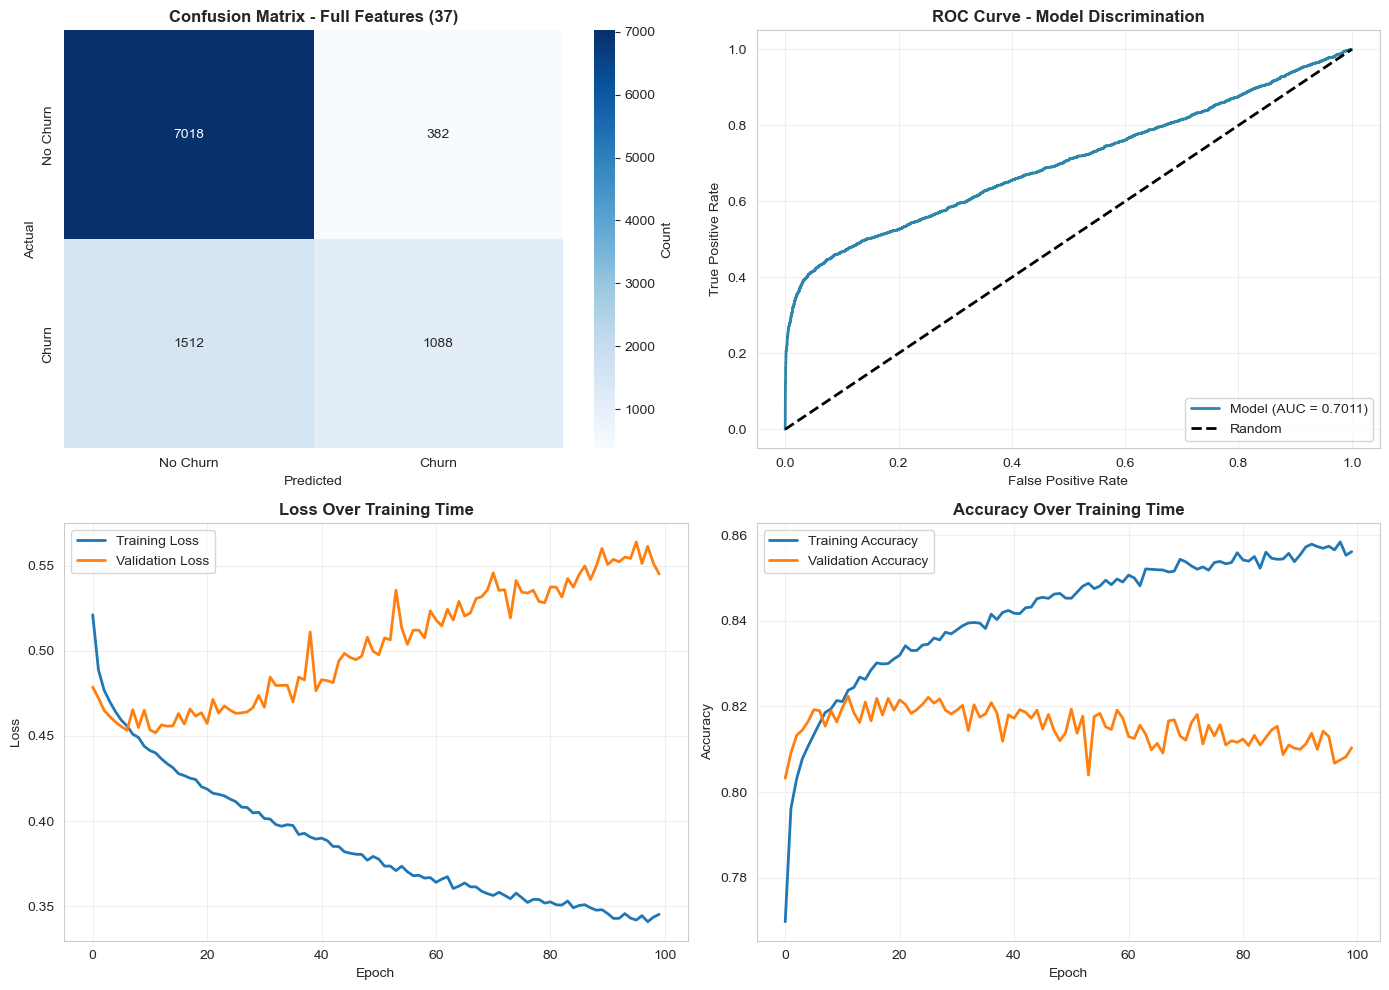

Feature selectio

Top 15 Most Important Features:
----------------------------------------------------------------------
 1. PaymentDelinquencyStatus            → 0.0733
 2. CompetitorIndex                     → 0.0623
 3. SupportTicketIntensity              → 0.0596
 4. UsageChangePct                      → 0.0526
 5. TenureMonths                        → 0.0494
 6. MonthlyCharges                      → 0.0480
 7. TicketsResolutionTime               → 0.0454
 8. AvgMonthlyCharge                    → 0.0443
 9. LoginsPerMonth                      → 0.0406
10. TotalCharges                        → 0.0377
11. ContractAutoRenew                   → 0.0376
12. LoginsLastMonth                     → 0.0346
13. TicketsOpened                       → 0.0338
14. Age                                 → 0.0338
15. RFMScore                            → 0.0251

   ✓ Saved: feature_importance.png


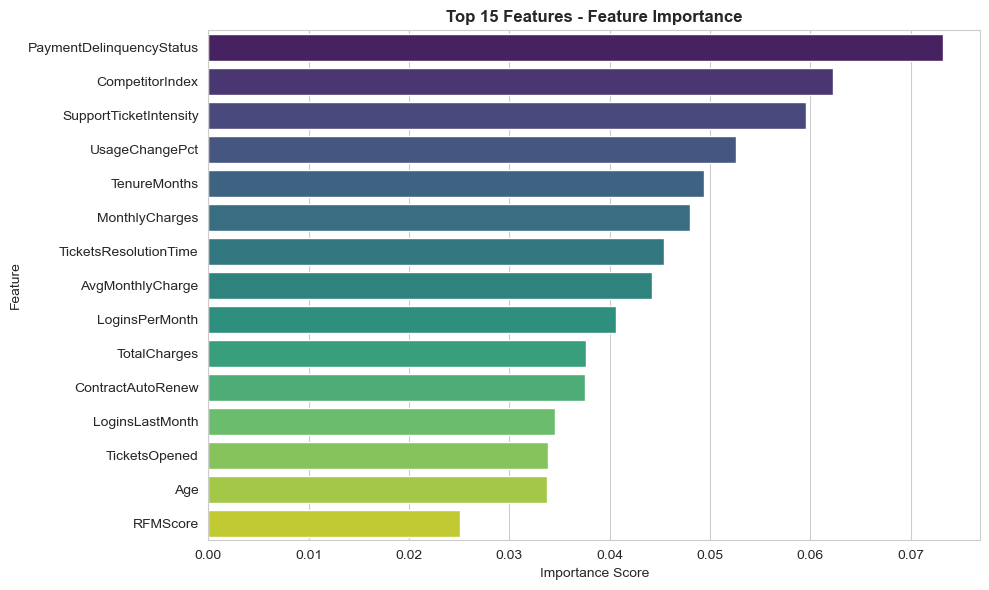

Training on selected features
Using 15 features instead of 57
Features: PaymentDelinquencyStatus, CompetitorIndex, SupportTicketIntensity, UsageChangePct, TenureMonths...

 Training simpler model...

Simpler Model Results:
   Accuracy: 0.8398 (83.98%)
   ROC-AUC:  0.7420
Model comparision

                     Model  Accuracy  ROC-AUC  Precision  Recall  Features
  Full Model (37 features)     0.811    0.701      0.740   0.418        37
Simple Model (15 features)     0.840    0.742      0.895   0.435        15

   ✓ Saved: model_comparison.png


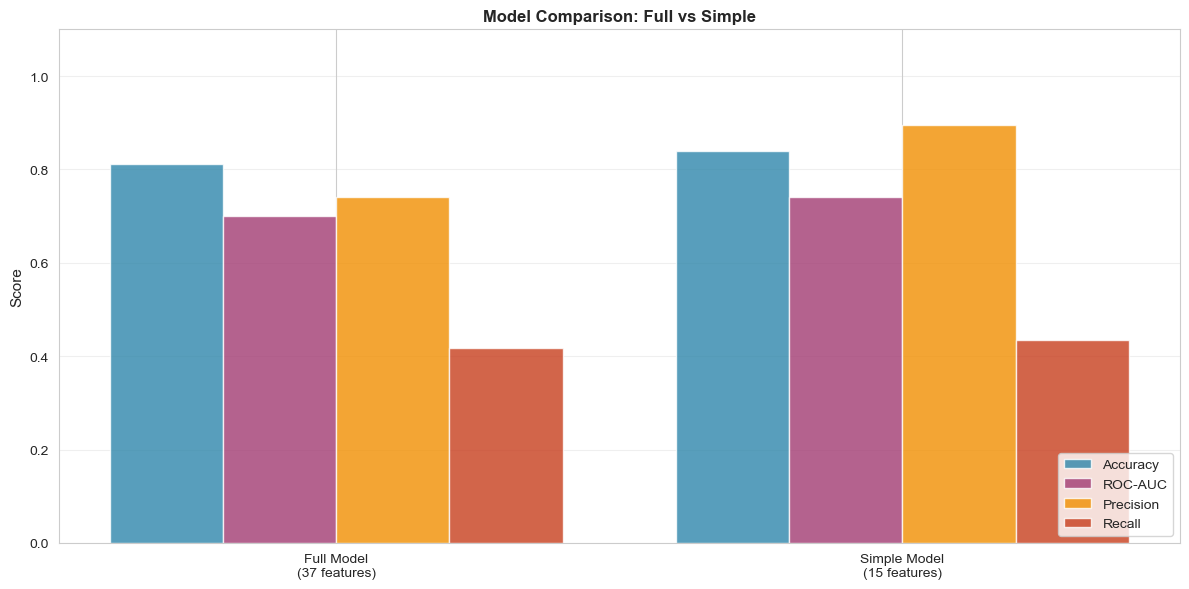

Summary and recommendation

KEY FINDINGS:
   • Dataset: 37 original features
   • Best Accuracy: 83.98%
   • Best ROC-AUC: 0.7420
   • Top Feature: PaymentDelinquencyStatus
   • Top 3 Features: PaymentDelinquencyStatus, CompetitorIndex, SupportTicketIntensity

 RECOMMENDED: Simple Model
    Accuracy: 83.98% (vs 81.06%)
    Uses only 15 features - simpler and faster

NEXT STEPS:
   1. Review the 3 saved visualizations
   2. Choose preferred model (full or simple)
   3. Save model for deployment: model.save('churn_model.h5')
   4. Use for predictions on new customers
   5. Monitor accuracy over time and retrain quarterly

 BUSINESS INSIGHTS:
   • Recall: 41.85% - Catching 42% of actual churners
   • Precision: 74.01% - 74% of alerts are true churners
   • Use for: Targeted retention campaigns
   • Focus on: Top 3 features for intervention

Done!


In [145]:
# Step 1 import
#pip install tensorflow - Installing libraries required.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier

import time

# ================================================================
# Step 2 Load dataset
print("Step 2 Load dataset")
FILE_PATH = 'C:\Windows\System32\Srishti\IS6052\Final\Omni_Churn_Data_Prepared.xlsx'

df = pd.read_excel(FILE_PATH)
print(f"data shape: {df.shape}")
print(f"   Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
print("Data loaded")

# ==================================================================
# Step 3 Preparing data
print("Step 3 preparing dataset")

# Removing custID as it is not useful for prediction
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)
    print("Removed CustomerID")

# Seperating features and targets
X = df.drop('Churn', axis=1)
y = df['Churn']
print(f"Separated features ({X.shape[1]}) and target")

#  STEP 4: Encode Categorical Features
print(" STEP 4: Encode Categorical Features")

# Find categorical cols
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"The number of categorical cols{len(categorical_cols)}")

# Encoding categorical features
label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"   ✓ Encoded '{col}' ({len(le.classes_)} categories)")


# Scaling features
print("Step 5: Scaling features")
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)
print(f"All {X_scaled.shape[1]} features scaled")

# STEP 6: Split Data
print("# STEP 6: Split Data")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Total features: {X_train.shape[1]}")
print(f"Churn rate (train): {y_train.mean():.2%}")
print(f"Churn rate (test): {y_test.mean():.2%}\n")


# Step 7 build neural network
print("Step 7 build neural network")

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.2),  # Prevent overfitting

    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(32, activation='relu'),

    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# STEP 8: Train the Model
print("Step 8: train model")
start_time = time.time()
history = model.fit(
    X_train, y_train,
    epochs=100,  # More epochs for complex data
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

training_time = time.time() - start_time

print(f"Training complete! Time: {training_time:.2f}s\n")

# STEP 9: Make Predictions

print("Step 9: making prediction")
y_proba = model.predict(X_test, verbose=0).flatten()
y_pred = (y_proba > 0.5).astype(int)

# STEP 10: Evaluate Performance
print("Step 10 Evaluate performance")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:   {accuracy:.4f} ({accuracy:.2%})")
print(f"Precision:  {precision:.4f} ({precision:.2%})")
print(f"Recall:     {recall:.4f} ({recall:.2%})")
print(f"F1 Score:   {f1:.4f}")
print(f"ROC-AUC:    {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion Matrix
tn, fp, fn, tp = cm.flatten()
print(f"\n Confusion Matrix Breakdown:")
print(f"   True Negatives (TN={tn:4d}):  Correct 'No Churn' predictions")
print(f"   False Positives (FP={fp:4d}): Predicted churn but didn't ")
print(f"   False Negatives (FN={fn:4d}): Actual churn but missed ")
print(f"   True Positives (TP={tp:4d}):  Correct 'Churn' predictions")

# STEP 11: Visualize Results
print("Visualize result")

# Plot 1: Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Full Features (37)', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')


# Plot 2: ROC Curve
plt.subplot(2, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, lw=2, label=f'Model (AUC = {auc:.4f})', color='#2E86AB')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Discrimination', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Plot 3: Training History - Loss
plt.subplot(2, 2, 3)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Training Time', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)


# Plot 4: Training History - Accuracy
plt.subplot(2, 2, 4)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Training Time', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance_full.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved: model_performance_full.png")
plt.show()


# STEP 12: Feature Selection
print("Feature selectio")
# Using random forest as secondary algo for feature selection

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)
print(f"\nTop 15 Most Important Features:")
print("-" * 70)
for i, (feat, imp) in enumerate(zip(feature_importance['Feature'].head(15),
                                     feature_importance['Importance'].head(15)), 1):
    print(f"{i:2d}. {feat:35s} → {imp:.4f}")

# Visualize top features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature',
            palette='viridis')
plt.title('Top 15 Features - Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("\n   ✓ Saved: feature_importance.png")
plt.show()


# Step 13 Train on selected features
print("Training on selected features")
selected_features = feature_importance['Feature'].head(15).tolist()
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

print(f"Using {len(selected_features)} features instead of {X_train.shape[1]}")
print(f"Features: {', '.join(selected_features[:5])}...")

# Simpler model for selected features
model_simple = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(len(selected_features),)),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(32, activation='relu'),

    keras.layers.Dense(1, activation='sigmoid')
])

model_simple.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("\n Training simpler model...\n")

history_simple = model_simple.fit(
    X_train_sel, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluate simple model
y_proba_simple = model_simple.predict(X_test_sel, verbose=0).flatten()
y_pred_simple = (y_proba_simple > 0.5).astype(int)

accuracy_simple = accuracy_score(y_test, y_pred_simple)
auc_simple = roc_auc_score(y_test, y_proba_simple)
cm_simple = confusion_matrix(y_test, y_pred_simple)

print(f"Simpler Model Results:")
print(f"   Accuracy: {accuracy_simple:.4f} ({accuracy_simple:.2%})")
print(f"   ROC-AUC:  {auc_simple:.4f}")


# STEP 14: Compare Both Models

print("Model comparision")
comparison_data = pd.DataFrame({
    'Model': ['Full Model (37 features)', 'Simple Model (15 features)'],
    'Accuracy': [accuracy, accuracy_simple],
    'ROC-AUC': [auc, auc_simple],
    'Precision': [precision, precision_score(y_test, y_pred_simple)],
    'Recall': [recall, recall_score(y_test, y_pred_simple)],
    'Features': [37, 15]
})

print("\n" + comparison_data.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(2)
width = 0.2

metrics_to_plot = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, metric in enumerate(metrics_to_plot):
    values = comparison_data[metric].values
    ax.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.8)

ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison: Full vs Simple', fontsize=12, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Full Model\n(37 features)', 'Simple Model\n(15 features)'])
ax.legend(loc='lower right')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\n   ✓ Saved: model_comparison.png")
plt.show()


# Step 15: Summary and reccoendation
print("Summary and recommendation")



print(f"\nKEY FINDINGS:")
print(f"   • Dataset: 37 original features")
print(f"   • Best Accuracy: {max(accuracy, accuracy_simple):.2%}")
print(f"   • Best ROC-AUC: {max(auc, auc_simple):.4f}")
print(f"   • Top Feature: {feature_importance.iloc[0]['Feature']}")
print(f"   • Top 3 Features: {', '.join(feature_importance.head(3)['Feature'].tolist())}")

if accuracy >= accuracy_simple:
    print(f"\nRECOMMENDED: Full Model")
    print(f"    Accuracy: {accuracy:.2%} (vs {accuracy_simple:.2%})")
    print(f"    Uses all 37 features for maximum predictive power")
else:
    print(f"\n RECOMMENDED: Simple Model")
    print(f"    Accuracy: {accuracy_simple:.2%} (vs {accuracy:.2%})")
    print(f"    Uses only 15 features - simpler and faster")

print(f"\nNEXT STEPS:")
print(f"   1. Review the 3 saved visualizations")
print(f"   2. Choose preferred model (full or simple)")
print(f"   3. Save model for deployment: model.save('churn_model.h5')")
print(f"   4. Use for predictions on new customers")
print(f"   5. Monitor accuracy over time and retrain quarterly")

print(f"\n BUSINESS INSIGHTS:")
print(f"   • Recall: {recall:.2%} - Catching {recall:.0%} of actual churners")
print(f"   • Precision: {precision:.2%} - {precision:.0%} of alerts are true churners")
print(f"   • Use for: Targeted retention campaigns")
print(f"   • Focus on: Top 3 features for intervention")

print("\n" + "=" * 70)
print("Done!")


### 2. Decision Tree

Step 2 loading data
Data loaded! Shape: (50000, 59)
Rows: 50000, Columns: 59

Step 3 Preparing data
Removed CustomerID
Separated features (57) and target

Encoding categorical features
Found 8 categorical columns
Encoded 8 categorical columns
New features counts after encoding: 96

Step 5 spilt data training and testing
Training samples: 35000 (70%)
Testing samples: 15000 (30%)
Total features: 96
Churn rate (train): 26.00%
Churn rate (test): 26.00%

Step 6 Feature scaling
Features scaled to mean=0, std=1
StandardScaler improves Decision Tree performance

Step 7 Build basic decision
Simple Decision Tree created!
Step 8 Evaluation
Accuracy:   0.7987 (79.87%)
Precision:  0.7840 (78.40%)
Recall:     0.3118 (31.18%)
F1 Score:   0.4462
ROC-AUC:    0.7093

 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.80      0.97      0.88     11100
       Churn       0.78      0.31      0.45      3900

    accuracy                           0.80     1500

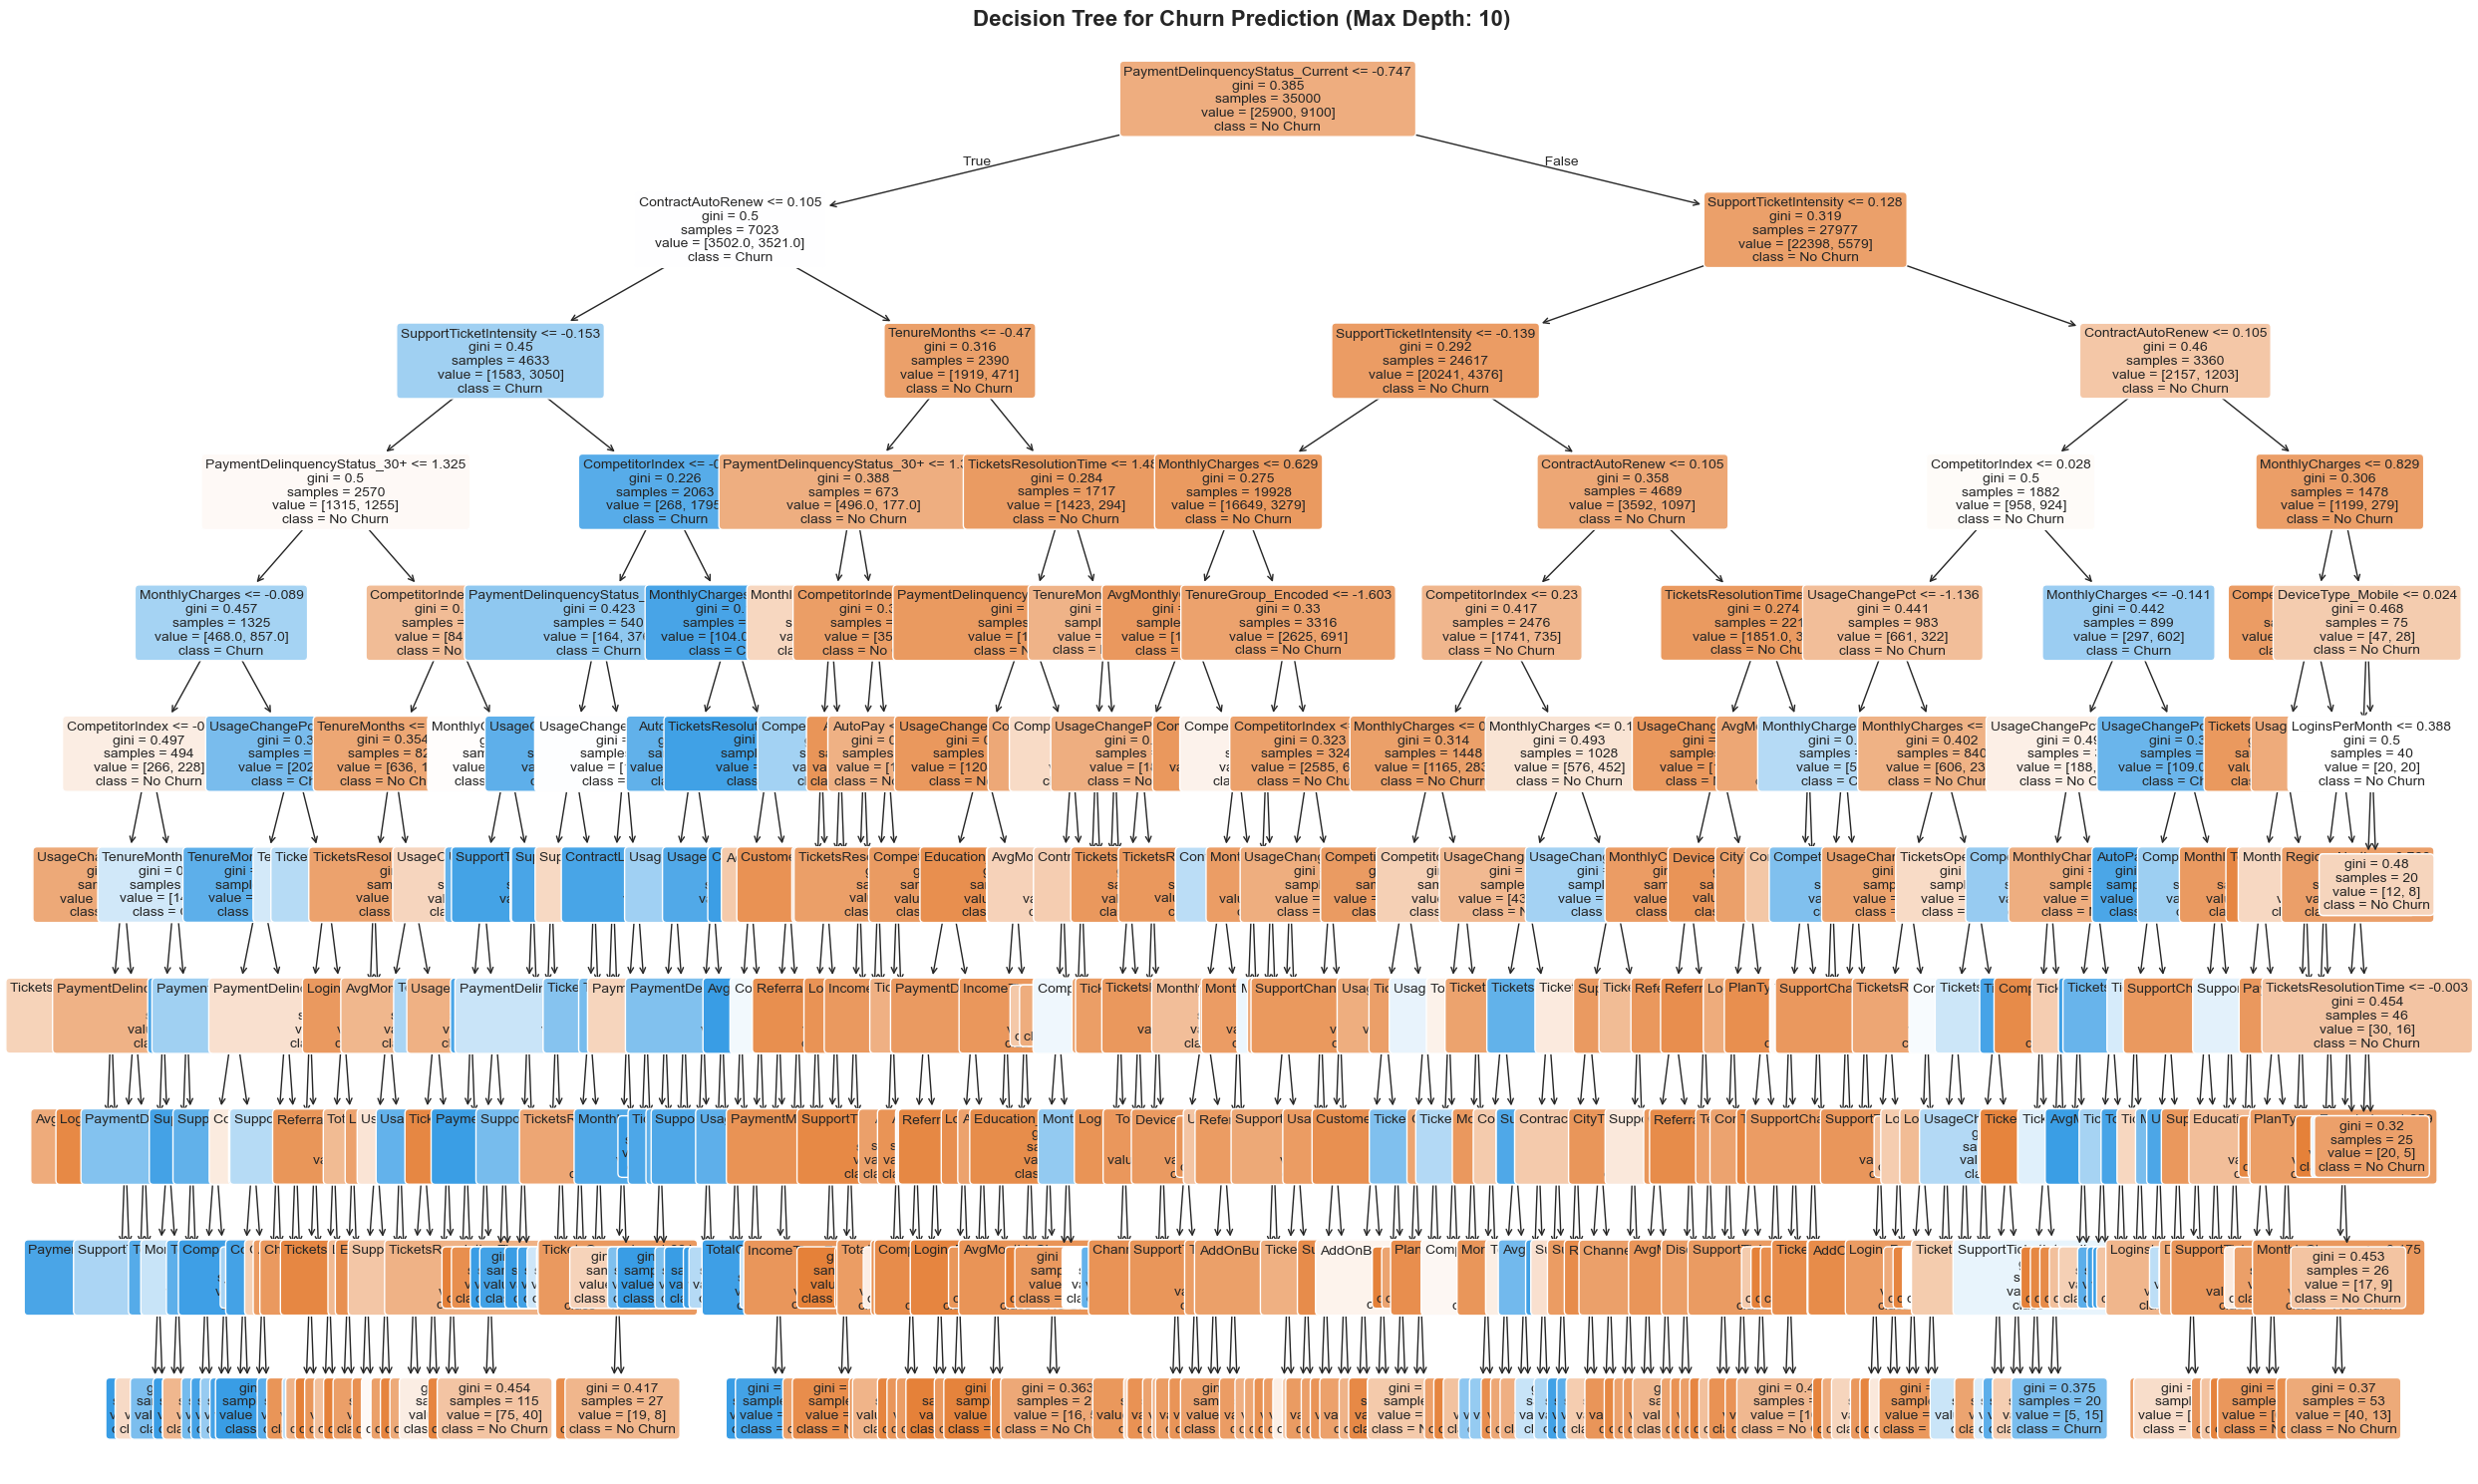

Step 13 featurs importance
Top 15 Most Important Features:
 1. PaymentDelinquencyStatus_Current         → 0.2281
 2. ContractAutoRenew                        → 0.1945
 3. SupportTicketIntensity                   → 0.1433
 4. CompetitorIndex                          → 0.1024
 5. MonthlyCharges                           → 0.0806
 6. UsageChangePct                           → 0.0692
 7. PaymentDelinquencyStatus_30+             → 0.0431
 8. TicketsResolutionTime                    → 0.0314
 9. TenureMonths                             → 0.0236
10. TotalCharges                             → 0.0113
11. TicketsOpened                            → 0.0094
12. AvgMonthlyCharge                         → 0.0088
13. AutoPay                                  → 0.0081
14. PaymentDelinquencyStatus_60+             → 0.0078
15. LoginsPerMonth                           → 0.0058

   ✓ Saved: dt_feature_importance.png


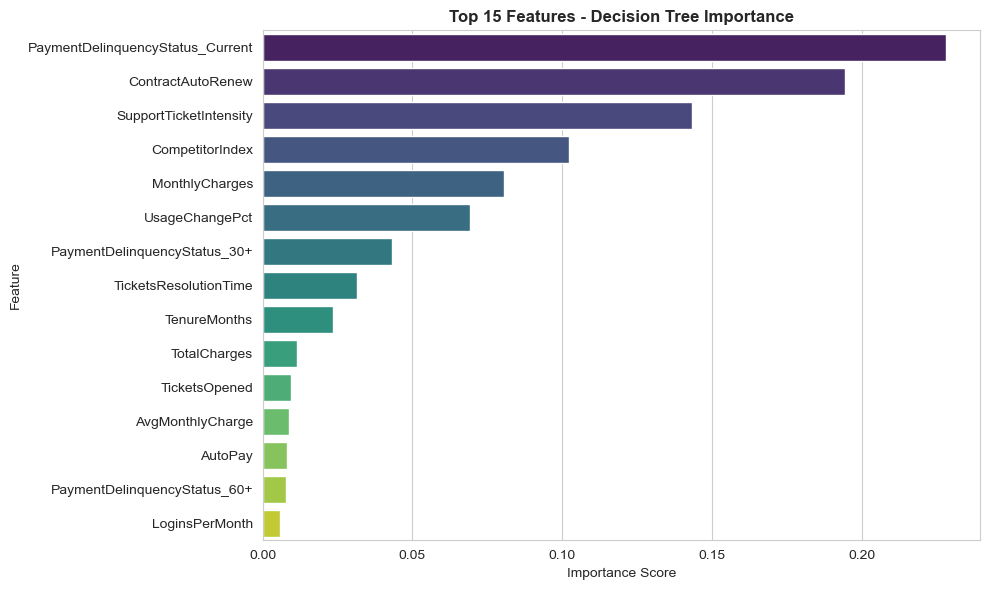

Step 14 Visualize performance
   ✓ Saved: decision_tree_performance.png


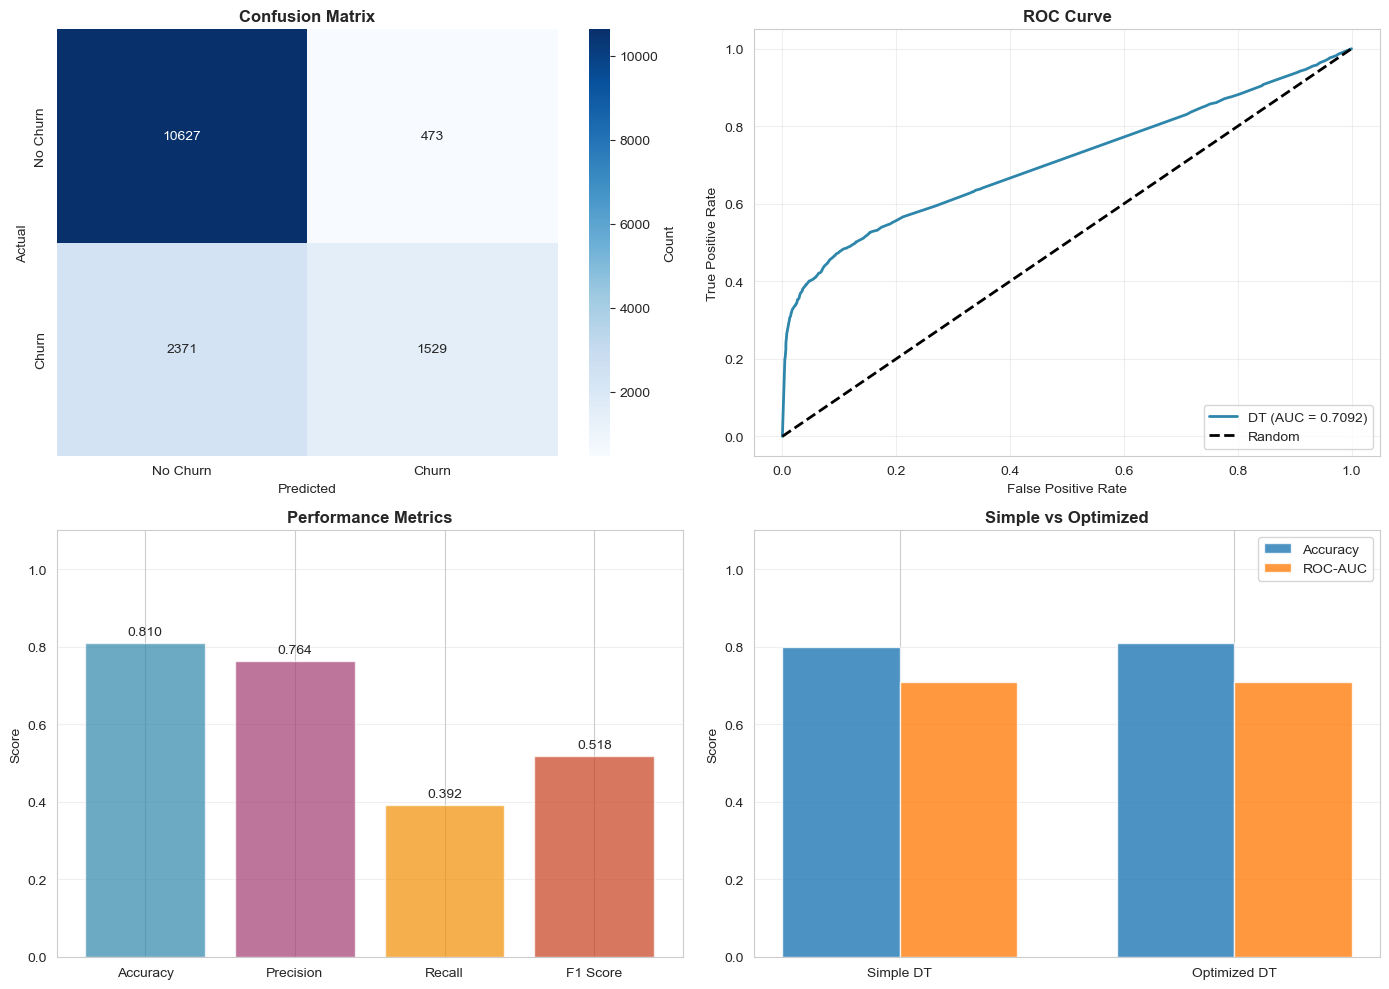

Training Random Forest for comparison...
Random Forest trained!
   Accuracy: 0.8157 (81.57%)
   ROC-AUC:  0.7309

Step 16 Final comparision

        Model  Accuracy  Precision  Recall  ROC-AUC
    Simple DT     0.799      0.784   0.312    0.709
 Optimized DT     0.810      0.764   0.392    0.709
Random Forest     0.816      0.930   0.315    0.731

WINNER: Random Forest with 81.57% accuracy
Step 17 Summary and recommendation

KEY FINDINGS:
   • Best Model: Random Forest
   • Accuracy: 81.57%
   • Recall: 31.49% (% of churners found)
   • Precision: 92.96%
   • ROC-AUC: 0.7309

DECISION TREE INSIGHTS:
   • Tree Depth: 10
   • Top Feature: PaymentDelinquencyStatus_Current
   • Top 3 Features: PaymentDelinquencyStatus_Current, ContractAutoRenew, SupportTicketIntensity

 NEXT STEPS:
   1. Review the saved visualizations
   2. Use Random Forest for predictions
   3. Focus retention on top 3 features
   4. Monitor model accuracy monthly
   5. Retrain quarterly with new data

BUSINESS RECOMMEN

In [147]:
#Decision tree

#Step 1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier

import time


# STEP 2: Load Your Excel File
print("Step 2 loading data")
FILE_PATH = 'C:\Windows\System32\Srishti\IS6052\Final\Omni_Churn_Data_Prepared.xlsx'
df = pd.read_excel(FILE_PATH)

print(f"Data loaded! Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# STEP 3: Prepare Data
print("Step 3 Preparing data")

# Remove CustomerID (not useful for prediction)
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)
    print("Removed CustomerID")

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Separated features ({X.shape[1]}) and target")

# STEP 4: Encode Categorical Features

print(f"\nEncoding categorical features")

# Find categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Found {len(categorical_cols)} categorical columns")

# One-Hot Encoding for categorical features

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Encoded {len(categorical_cols)} categorical columns")
print(f"New features counts after encoding: {X_encoded.shape[1]}\n")

# STEP 5: Split Data into Training and Testing

print("Step 5 spilt data training and testing")
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)} (70%)")
print(f"Testing samples: {len(X_test)} (30%)")
print(f"Total features: {X_train.shape[1]}")
print(f"Churn rate (train): {y_train.mean():.2%}")
print(f"Churn rate (test): {y_test.mean():.2%}\n")


# STEP 6: Feature Scaling (StandardScaler)
print("Step 6 Feature scaling")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting back to dataframe for better tracking
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Features scaled to mean=0, std=1")
print("StandardScaler improves Decision Tree performance\n")

# STEP 7: Build Basic Decision Tree (No Tuning)
print("Step 7 Build basic decision")

# Create a simple decision tree
dt_simple = DecisionTreeClassifier(
    max_depth=5,           # Limit tree depth (prevent overfitting)
    min_samples_leaf=20,   # Minimum samples in leaf node
    random_state=42
)

dt_simple.fit(X_train_scaled, y_train)
print("Simple Decision Tree created!")

# STEP 8: Evaluate Simple Decision Tree

print("Step 8 Evaluation")
y_pred_simple = dt_simple.predict(X_test_scaled)
y_proba_simple = dt_simple.predict_proba(X_test_scaled)[:, 1]


accuracy_simple = accuracy_score(y_test, y_pred_simple)
precision_simple = precision_score(y_test, y_pred_simple)
recall_simple = recall_score(y_test, y_pred_simple)
f1_simple = f1_score(y_test, y_pred_simple)
auc_simple = roc_auc_score(y_test, y_proba_simple)
cm_simple = confusion_matrix(y_test, y_pred_simple)


print(f"Accuracy:   {accuracy_simple:.4f} ({accuracy_simple:.2%})")
print(f"Precision:  {precision_simple:.4f} ({precision_simple:.2%})")
print(f"Recall:     {recall_simple:.4f} ({recall_simple:.2%})")
print(f"F1 Score:   {f1_simple:.4f}")
print(f"ROC-AUC:    {auc_simple:.4f}")

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred_simple, target_names=['No Churn', 'Churn']))

# Confusion Matrix Interpretation
tn, fp, fn, tp = cm_simple.flatten()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN={tn:4d}):  Correct 'No Churn'")
print(f"False Positives (FP={fp:4d}): Predicted churn but didn't")
print(f"False Negatives (FN={fn:4d}): Actual churn but missed")
print(f"True Positives (TP={tp:4d}):  Correct 'Churn'")


# STEP 9: Try Different Tree Depths
print("STEP 9: Try Different Tree Depths")

depths = [3, 5, 7, 10, 15, None]
results = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=20,
        random_state=42
    )
    dt.fit(X_train_scaled, y_train)

    y_pred = dt.predict(X_test_scaled)
    y_proba = dt.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    depth_label = f"Unlimited" if depth is None else str(depth)
    print(f"Depth {depth_label:10s} → Accuracy: {acc:.4f}, ROC-AUC: {auc:.4f}")

    results.append({
        'depth': depth_label,
        'accuracy': acc,
        'auc': auc
    })

    results_df = pd.DataFrame(results)
    best_depth_idx = results_df['accuracy'].idxmax()
    best_depth = depths[best_depth_idx]
    best_accuracy = results_df.loc[best_depth_idx, 'accuracy']

    print(f"Best depth found: {results_df.loc[best_depth_idx, 'depth']} with accuracy {best_accuracy:.4f}")

# STEP 10: Train Optimized Decision Tree
print("Step 10 Train Optimized Decision Tree")

dt_optimized = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=20,
    random_state=42
)
dt_optimized.fit(X_train_scaled, y_train)

print(f"Optimized Decision Tree trained with max_depth={best_depth}\n")

# STEP 11: Evaluate Optimized Decision Tree

print("Step 11 Evauate optimized decision tree")

y_pred_opt = dt_optimized.predict(X_test_scaled)
y_proba_opt = dt_optimized.predict_proba(X_test_scaled)[:, 1]

accuracy_opt = accuracy_score(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)
auc_opt = roc_auc_score(y_test, y_proba_opt)
cm_opt = confusion_matrix(y_test, y_pred_opt)

print(f"Accuracy:   {accuracy_opt:.4f} ({accuracy_opt:.2%})")
print(f"Precision:  {precision_opt:.4f} ({precision_opt:.2%})")
print(f"Recall:     {recall_opt:.4f} ({recall_opt:.2%})")
print(f"F1 Score:   {f1_opt:.4f}")
print(f"ROC-AUC:    {auc_opt:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_opt, target_names=['No Churn', 'Churn']))

# STEP 12: Visualize Decision Tree
print("STEP 12 Visualize")

plt.figure(figsize=(25, 15))
plot_tree(
    dt_optimized,
    feature_names=X_train_scaled.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree for Churn Prediction (Max Depth: {best_depth})",
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved: decision_tree_visualization.png")
plt.show()

# STEP 13: Feature Importance
print("Step 13 featurs importance")
feature_importances = dt_optimized.feature_importances_
feature_names = X_train_scaled.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)


print("Top 15 Most Important Features:")

for i, (feat, imp) in enumerate(zip(importance_df['Feature'].head(15),
                                     importance_df['Importance'].head(15)), 1):
    print(f"{i:2d}. {feat:40s} → {imp:.4f}")

# Visualize feature importance

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature',
            palette='viridis')
plt.title('Top 15 Features - Decision Tree Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=300, bbox_inches='tight')
print("\n   ✓ Saved: dt_feature_importance.png")
plt.show()

# STEP 14: Visualize Performance Metrics
print("Step 14 Visualize performance")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Confusion Matrix
plt.subplot(2, 2, 1)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Plot 2: ROC Curve
plt.subplot(2, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba_opt)
plt.plot(fpr, tpr, lw=2, label=f'DT (AUC = {auc_opt:.4f})', color='#2E86AB')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Plot 3: Metrics Comparison
plt.subplot(2, 2, 3)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy_opt, precision_opt, recall_opt, f1_opt]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
plt.bar(metrics, values, color=colors, alpha=0.7)
plt.ylabel('Score')
plt.title('Performance Metrics', fontweight='bold')
plt.ylim([0, 1.1])
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.grid(axis='y', alpha=0.3)

# Plot 4: Simple vs Optimized Comparison
plt.subplot(2, 2, 4)
models = ['Simple DT', 'Optimized DT']
accuracies = [accuracy_simple, accuracy_opt]
aucs = [auc_simple, auc_opt]
x = np.arange(len(models))
width = 0.35
plt.bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.8)
plt.bar(x + width/2, aucs, width, label='ROC-AUC', alpha=0.8)
plt.ylabel('Score')
plt.title('Simple vs Optimized', fontweight='bold')
plt.xticks(x, models)
plt.legend()
plt.ylim([0, 1.1])
plt.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.savefig('decision_tree_performance.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved: decision_tree_performance.png")
plt.show()


# Stp 15 Comparision with random forest
print("Training Random Forest for comparison...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Random Forest trained!")
print(f"   Accuracy: {accuracy_rf:.4f} ({accuracy_rf:.2%})")
print(f"   ROC-AUC:  {auc_rf:.4f}\n")


# STEP 16: Final Comparison
print("Step 16 Final comparision")

comparison_df = pd.DataFrame({
    'Model': ['Simple DT', 'Optimized DT', 'Random Forest'],
    'Accuracy': [accuracy_simple, accuracy_opt, accuracy_rf],
    'Precision': [precision_simple, precision_opt, precision_score(y_test, y_pred_rf)],
    'Recall': [recall_simple, recall_opt, recall_score(y_test, y_pred_rf)],
    'ROC-AUC': [auc_simple, auc_opt, auc_rf],
})

print("\n" + comparison_df.to_string(index=False))

# Find best model
best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_accuracy_val = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"\nWINNER: {best_model_name} with {best_accuracy_val:.2%} accuracy")

# STEP 17: Summary & Recommendations

print("Step 17 Summary and recommendation")

print(f"\nKEY FINDINGS:")
print(f"   • Best Model: {best_model_name}")
print(f"   • Accuracy: {best_accuracy_val:.2%}")
print(f"   • Recall: {comparison_df.loc[best_model_idx, 'Recall']:.2%} (% of churners found)")
print(f"   • Precision: {comparison_df.loc[best_model_idx, 'Precision']:.2%}")
print(f"   • ROC-AUC: {comparison_df.loc[best_model_idx, 'ROC-AUC']:.4f}")

print(f"\nDECISION TREE INSIGHTS:")
print(f"   • Tree Depth: {best_depth}")
print(f"   • Top Feature: {importance_df.iloc[0]['Feature']}")
print(f"   • Top 3 Features: {', '.join(importance_df.head(3)['Feature'].tolist())}")

print(f"\n NEXT STEPS:")
print(f"   1. Review the saved visualizations")
print(f"   2. Use {best_model_name} for predictions")
print(f"   3. Focus retention on top 3 features")
print(f"   4. Monitor model accuracy monthly")
print(f"   5. Retrain quarterly with new data")


print(f"\nBUSINESS RECOMMENDATIONS:")
print(f"   • High Recall ({comparison_df.loc[best_model_idx, 'Recall']:.0%}): Find most churners")
print(f"   • High Precision ({comparison_df.loc[best_model_idx, 'Precision']:.0%}): Reliable predictions")
print(f"   • Focus: Interventions on top 3 features listed above")
print(f"   • Deploy: Use for scoring new customers")

print("\n" + "=" * 70)
print("Done!")


### 3. Logistic Regression

Step 1 Loading Dataset
Dataset Shape: (50000, 59)
Target Variable (Churn) Distribution:
Churn
0    37000
1    13000
Name: count, dtype: int64
Features: (50000, 57) columns
Samples: 50000 rows
Handling categorical
Features after encoding: 96 columns
STEP 3: TRAIN-TEST SPLIT
Training set: 35000 samples (70.0%)
Testing Set: 15000 samples (30.0%)
STEP 4: FEATURE SCALING (StandardScaler)
Features scaled to mean=0, std=1
STEP 5: HYPERPARAMETER TUNING
Tuning parameters: C, penalty, class_weight
✓ Best Cross-Validation ROC-AUC: 0.7341
✓ Best Parameters: {'C': 0.01, 'class_weight': None, 'penalty': 'l1'}
Step 6 Model evaluation
Accuracy: 0.8281
ROC-AUC Score: 0.7359

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.89     11100
           1       0.87      0.40      0.55      3900

    accuracy                           0.83     15000
   macro avg       0.85      0.69      0.72     15000
weighted avg       0.83      0.83     

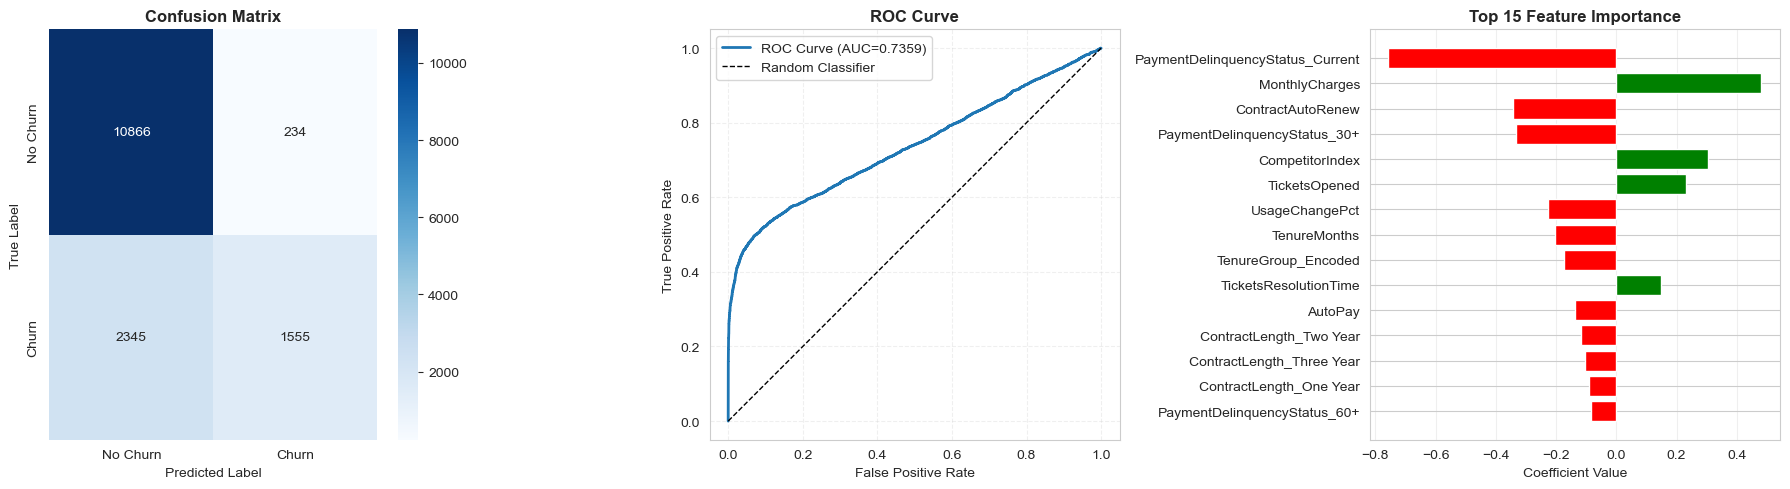

 Visualization DOne


In [148]:
#Logistic Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

# Step 1 Load and prepare data

print("Step 1 Loading Dataset")
df = pd.read_excel('C:\Windows\System32\Srishti\IS6052\Final\Omni_Churn_Data_Prepared.xlsx') #Change path according to your file path
print(f"Dataset Shape: {df.shape}")
print(f"Target Variable (Churn) Distribution:")
print(df['Churn'].value_counts())

# Seperate features X and target y
X = df.drop(['CustomerID', 'Churn'], axis=1) # Remove ID column as it's not useful
y = df['Churn']

print(f"Features: {X.shape} columns")
print(f"Samples: {X.shape[0]} rows")

# Step 2 Handle Categorical Variable
print("Handling categorical")

# One-hot encoding for categorical variables
X = pd.get_dummies(X, columns=X.select_dtypes(include=['object']).columns, drop_first=True)

#Fill any Nan values with column mean
X = X.fillna(X.mean())
print(f"Features after encoding: {X.shape[1]} columns")

# Step 3 Train - test Split
print("STEP 3: TRAIN-TEST SPLIT")

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Step 4 Feature Scaling
print("STEP 4: FEATURE SCALING (StandardScaler)")

# Standardize features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled to mean=0, std=1")


# STEP 5: HYPERPARAMETER TUNING WITH GRIDSEARCHCV
print("STEP 5: HYPERPARAMETER TUNING")

# Define cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#  Define parameter grid for tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

# Perform grid search

grid_search = GridSearchCV(
    estimator=LogisticRegression(solver='liblinear', max_iter=5000),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

print("Tuning parameters: C, penalty, class_weight")
grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_
best_model = grid_search.best_estimator_

print(f"✓ Best Cross-Validation ROC-AUC: {best_cv_score:.4f}")
print(f"✓ Best Parameters: {best_params}")

# STEP 6: MODEL EVALUATION

print("Step 6 Model evaluation")

# Make prediction
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print()
print("Classification Report:")
print(class_report)
print()

# STEP 7: VISUALIZATION
print("Visualization")

#  Figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 7.1 Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 7.2 ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC={roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.3)

# 7.3 Top 15 Feature Importance
feature_coeffs = best_model.coef_[0]
feature_names = X_train.columns
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': feature_coeffs
})
coef_df['Abs_Coef'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coef', ascending=True).tail(15)

axes[2].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=['green' if x > 0 else 'red' for x in coef_df['Coefficient']])
axes[2].set_xlabel('Coefficient Value')
axes[2].set_title('Top 15 Feature Importance', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()


print(" Visualization DOne")
print("=" * 80)


###### scikit-optimize libraries required to import

In [150]:
#pip install scikit-optimize


   ---------------------------------------- 0/2 [pyaml]
   ---------------------------------------- 0/2 [pyaml]
   -------------------- ------------------- 1/2 [scikit-optimize]
   -------------------- ------------------- 1/2 [scikit-optimize]
   -------------------- ------------------- 1/2 [scikit-optimize]
   -------------------- ------------------- 1/2 [scikit-optimize]
   ---------------------------------------- 2/2 [scikit-optimize]

Note: you may need to restart the kernel to use updated packages.


### 4. Random Forest

Data loaded. the shape is (50000, 59)
   Dimensions: 50000 rows, 59 columns
Dataset overview
  - Target Variable (Churn): [0 1]
  - Churn Distribution:
Churn
0    37000
1    13000
Name: count, dtype: int64
Features (X) shape: (50000, 58)
Target (y) shape: (50000,)

 Numerical Features (20): ['CustomerID', 'Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges']...
Categorical Features (8): ['ContractLength', 'AddOnBundle', 'ReferralSource', 'SupportChannelPreferred', 'ComplaintCategory']...
Preprocessing pipeline created
Training Set: 37500 samples (75.0%)
Testing Set: 12500 samples (25.0%)

Class Distribution (Churn):
   Train Set:
Churn
0    27750
1     9750
Name: count, dtype: int64
   Test Set:
Churn
0    9250
1    3250
Name: count, dtype: int64
Random Forest Pipeline Created

Starting Bayesian Optimization might take time..................
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each 

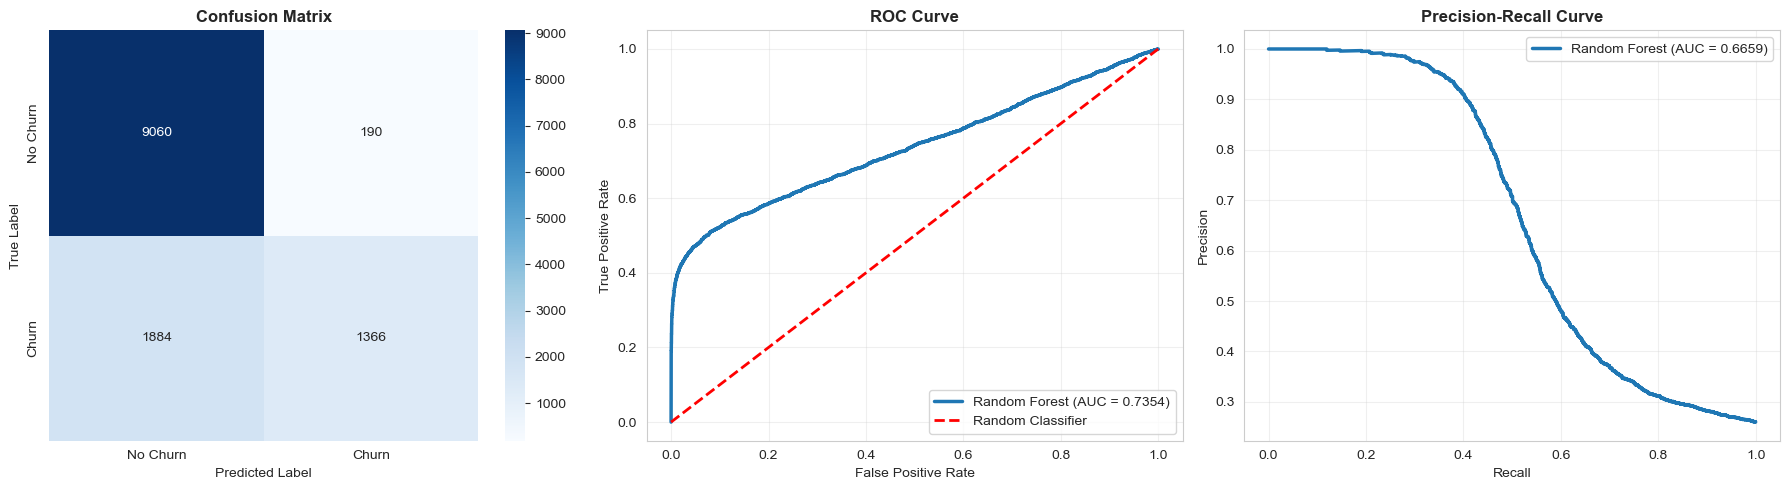

Evaluation visualizations generated and saved

Extracting feature importances:

Top 15 Most Important Features:
                              Feature  Importance
          num__SupportTicketIntensity       0.061
cat__PaymentDelinquencyStatus_Current       0.060
                 num__CompetitorIndex       0.055
                  num__UsageChangePct       0.046
                    num__TenureMonths       0.046
                  num__MonthlyCharges       0.044
         remainder__ContractAutoRenew       0.043
                num__AvgMonthlyCharge       0.039
           num__TicketsResolutionTime       0.038
                  num__LoginsPerMonth       0.037
                      num__CustomerID       0.037
                    num__TotalCharges       0.033
                   num__TicketsOpened       0.030
                 num__LoginsLastMonth       0.029
                             num__Age       0.028


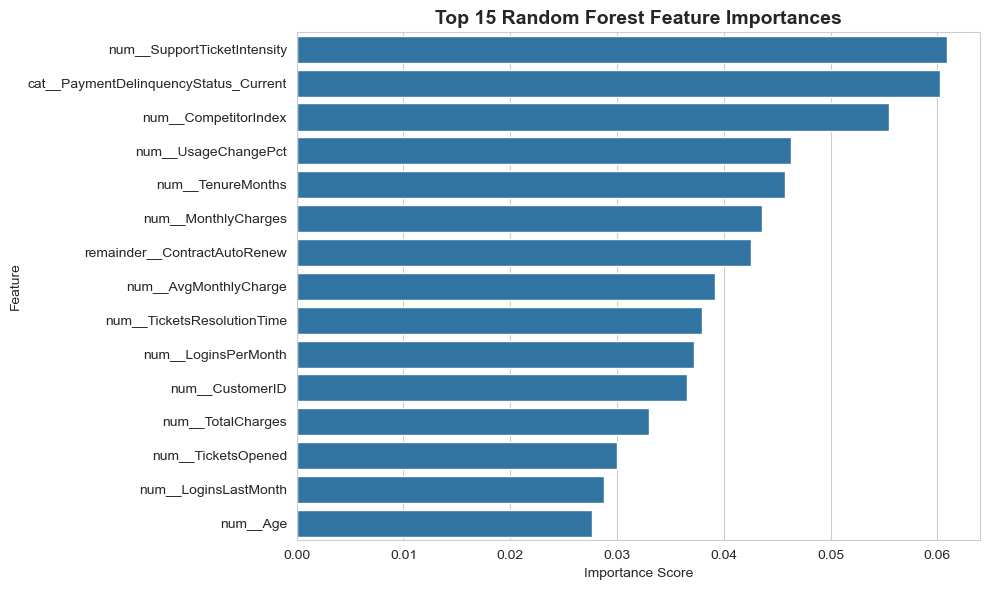


Feature importance visualization generated and saved.

Selected Top 8 Original Features for Subset Model:
   ['PaymentDelinquencyStatus', 'CustomerID', 'Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'LoginsLastMonth', 'TicketsOpened']

Training Random Forest on 8-feature subset...
Subset model trained

MODEL COMPARISON RESULTS
Metric          Full Model      Subset Model    Difference     
------------------------------------------------------------
Accuracy        0.8341          0.7836          +0.0505
ROC-AUC         0.7354          0.6828          +0.0526
F1-Score        0.5685          0.4591          +0.1093

Comparison Analysis:
   Notable performance loss: 0.0526 ROC-AUC
      Full model may be necessary for best performance

 RANDOM FOREST MODEL DEVELOPMENT COMPLETE

Model Performance Summary:
  • Accuracy:     0.8341
  • ROC-AUC:      0.7354
  • Precision:    0.8779
  • Recall:       0.4203
  • F1-Score:     0.5685

Key Findings:
  • Top predictor: num__SupportTick

In [156]:
#Random Forest
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# --- Bayesian Optimization Imports ---
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
# --- End Bayesian Optimization Imports ---

# Configure display and suppress warnings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')


# ==============================================================================================
# Step 1 load pre cleaned data
CHURN_DATA_PATH = 'C:\Windows\System32\Srishti\IS6052\Final\Omni_Churn_Data_Prepared.xlsx' #Change path according to your file path

try:
    df = pd.read_excel(CHURN_DATA_PATH)
    print(f"Data loaded. the shape is {df.shape}")
    print(f"   Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

except FileNotFoundError as e:
    print(f'File missing at: {CHURN_DATA_PATH}')
    raise


# Displaying basic iformation
print("Dataset overview")
print(f"  - Target Variable (Churn): {df['Churn'].unique()}")
print(f"  - Churn Distribution:\n{df['Churn'].value_counts()}")


# ==============================================================================================
# Step 2 Preparing targets and features
# In this step we are seperating independent variable x and dependent variable y


# The churn col is the target and custID is dropped as it is just an identifier
X = df.drop('Churn', axis=1) # to drop all feature except churn
y = df['Churn']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Identify the numerical and categorical features
# Numberical can be float/int col with more than 2 unique values (Continous, discrete)
# Categorical; object cols (Strings, categories)

numerical_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Now filter out the binary numericals, keeping only continous
numerical_features = [col for col in numerical_features if X[col].nunique() > 2]

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n Numerical Features ({len(numerical_features)}): {numerical_features[:5]}...")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features[:5]}...")


# ========================================================================================
# Step 3 creating preprocessing pipeline
# 1) Scaling the nuericals features (StandardScaler for normalization)
# 2) Encoding the categorical features (OneHotEncoder for dummy variables)

# Defining preprocessing transformations
preprocessor =  ColumnTransformer(
    transformers=[
        # Transformer 1: Scale numerical features to mean=0, std=1
        # This ensures all numerical features are on the same scale
        # (prevents features with larger ranges from dominating the model)
        ('num', StandardScaler(), numerical_features),

        # Transformer 2: One-Hot Encode categorical features
        # Converts categorical strings into binary dummy variables
        # E.g., Gender: [Male, Female] -> [Gender_Male, Gender_Female]
        # handle_unknown='ignore': Handles unseen categories in test data
        # sparse_output=False: Returns dense array (easier to work with)
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features)
    ],
    remainder='passthrough'  # Pass through any remaining columns unchanged
)

print('Preprocessing pipeline created')

# ==============================================================================
# Step 4 train test split
# Splitting data into training 75 and testing 25 percent
# stratify=y ensures the churn distribution is preserved in both sets
# random_state=42 ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.25, #splitting in 25 percent
    random_state=42, # Fixing seed for reproducibility
    stratify=y # Maintain churn class distribution in both sets
)

print(f"Training Set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing Set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nClass Distribution (Churn):")
print(f"   Train Set:\n{y_train.value_counts()}")
print(f"   Test Set:\n{y_test.value_counts()}")


# =============================================================================
# STEP 6: BAYESIAN OPTIMIZATION FOR HYPERPARAMETER TUNING
# Hyperparameter tuning finds the best configuration for Random Forest
# Bayesian Optimization is more efficient than Grid Search or Random Search
# It uses past trials to suggest promising hyperparameter combinations

# 1. Create random forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'  # Handle churn class imbalance
    ))
])

print("Random Forest Pipeline Created")

# 2)  Define hyperparameter search space for Bayesian Optimization
# # These hyperparameters control the structure and behavior of the Random Forest

param_space = {
    # n_estimators: Number of decision trees in the forest
    # More trees generally improve performance but increase computation time
    'classifier__n_estimators': Integer(100, 500, prior='uniform'),

    # max_depth: Maximum depth of each decision tree
    # Deeper trees capture more complex patterns but risk overfitting
    'classifier__max_depth': Integer(5, 20, prior='uniform'),

    # min_samples_split: Minimum samples needed to split a node
    # Higher values prevent overfitting by creating simpler trees
    'classifier__min_samples_split': Integer(2, 10, prior='uniform'),

    # min_samples_leaf: Minimum samples required at a leaf node
    # Ensures leaves have sufficient samples (prevents sparse trees)
    'classifier__min_samples_leaf': Integer(1, 5, prior='uniform'),

    # criterion: Function to measure split quality
    # 'gini': Gini impurity (faster)
    # 'entropy': Information gain (theoretically more principled)
    'classifier__criterion': Categorical(['gini', 'entropy'])
}

# 3. Perform bayesian search
print("\nStarting Bayesian Optimization might take time..................")
start_time = time.time()

bayes_search = BayesSearchCV(
    rf_pipeline,
    search_spaces=param_space,
    n_iter=10,             # Total optimization iterations
    cv=3,                  # 3-fold cross-validation
    scoring='roc_auc',     # Metric to optimize
    verbose=1,             # Print progress
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

# Fit the search on training data
bayes_search.fit(X_train, y_train)
end_time = time.time()

print(f"\nBayesian Optimization completed in {end_time - start_time:.2f} seconds")

# 4. Extract and display best hyperparameters
best_rf_model = bayes_search.best_estimator_
best_params = bayes_search.best_params_
best_score = bayes_search.best_score_

# Clean parameter names (remove 'classifier__' prefix for readability)
cleaned_params = {k.replace('classifier__', ''): v for k, v in best_params.items()}


print(f"\nBest Cross-Validation ROC-AUC: {best_score:.4f}")
print("\nBest Hyperparameters Found:")
for param, value in cleaned_params.items():
    print(f"   - {param}: {value}")


# ==========================================================================
# Step 7 : Model Evaluation on test sets

# Evaluate the tuned model on unseen test data using multiple metrics

# 1) Generate predictions
y_pred_test = best_rf_model.predict(X_test)
y_proba_test = best_rf_model.predict_proba(X_test)[:, 1]  # P(Churn=1)

print("Predictions generated on test set")

# 2) Calculate performance matrix
# Accuracy overall correctness
accuracy = best_rf_model.score(X_test, y_test)

# ROC-AUC: Area Under Receiver Operating Characteristic Curve
# Ranges 0-1; 0.5 = random, 1.0 = perfect
roc_auc = roc_auc_score(y_test, y_proba_test)

# Detailed classification metrics
classification_dict = classification_report(y_test, y_pred_test, output_dict=True)
precision = classification_dict['1']['precision']  # TP / (TP + FP)
recall = classification_dict['1']['recall']        # TP / (TP + FN)
f1 = classification_dict['1']['f1-score']          # Harmonic mean of precision and recall

# Confusion Matrix: TN, FP, FN, TP
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

print("PERFORMANCE METRICS (Test Set)")
print(f"Accuracy:  {accuracy:.4f} (Overall correctness)")
print(f"Precision: {precision:.4f} (Churn predictions that are correct)")
print(f"Recall:    {recall:.4f} (Actual churners correctly identified)")
print(f"F1-Score:  {f1:.4f} (Balance between precision & recall)")
print(f"ROC-AUC:   {roc_auc:.4f} (Discrimination ability)")

# ================================================================
# STEP 8: CROSS-VALIDATION

# Perform 5-fold cross-validation
cv_scores = cross_val_score(best_rf_model, X, y, cv=5, scoring='f1')

print(f"5-Fold Cross-Validation F1-Scores:")
print(f"   Fold scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"   Mean CV F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

if cv_scores.std() < 0.05:
    print("Low variance: Model is stable across different data splits")
else:
    print("High variance: Model performance varies across splits")

# ===============================================================================
# STEP 9: VISUALIZATION - EVALUATION METRICS

# Create 3 visualizations: Confusion Matrix, ROC Curve, Precision-Recall Curve
# Visualization 1: Confusion Matrix Heatmap

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')


# Visualization 2: ROC Curve
# Shows trade-off between True Positive Rate and False Positive Rate
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
axes[1].plot(fpr, tpr, linewidth=2.5, label=f'Random Forest (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Visualization 3: Precision-Recall Curve
# Shows trade-off between precision (exactness) and recall (coverage)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc = auc(recall_vals, precision_vals)
axes[2].plot(recall_vals, precision_vals, linewidth=2.5,
             label=f'Random Forest (AUC = {pr_auc:.4f})')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Evaluation visualizations generated and saved")

# STEP 10: FEATURE IMPORTANCE ANALYSIS 

print("\nExtracting feature importances:")

# 1. Get feature names from the fitted preprocessor
preprocessor = best_rf_model.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

# 2. Get feature importances from the trained Random Forest
rf_classifier = best_rf_model.named_steps['classifier']
importances = rf_classifier.feature_importances_

# 3. Build the importance DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))

# 4. Plot top 15 features
plt.figure(figsize=(10, 6))
top_15 = feature_importance_df.head(15)
sns.barplot(x='Importance', y='Feature', data=top_15)
plt.title('Top 15 Random Forest Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature importance visualization generated and saved.")


# ============================================================================================
# STEP 11: MODEL COMPARISON - FULL FEATURES VS. SELECTED SUBSET
# Train a second model using only the top 8 features
# Compare performance to assess if we can simplify the model

# 1. Select top 8 features (original feature names, not encoded)
# Extract original features from the encoded names

top_8_original_features = []
for feat in feature_importance_df['Feature'].head(8):
    # Match encoded names back to original features
    for orig_feat in categorical_features:
        if orig_feat in feat:
            if orig_feat not in top_8_original_features:
                top_8_original_features.append(orig_feat)
            break
    else:
        # If not a categorical feature, it's numerical
        if feat in numerical_features:
            top_8_original_features.append(feat)

# If we don't have 8 yet, add remaining numerical features
if len(top_8_original_features) < 8:
    for num_feat in numerical_features:
        if num_feat not in top_8_original_features and len(top_8_original_features) < 8:
            top_8_original_features.append(num_feat)


print(f"\nSelected Top 8 Original Features for Subset Model:")  #yeh
print(f"   {top_8_original_features}")

# 2. Prepare subset data
X_train_subset = X_train[top_8_original_features]
X_test_subset = X_test[top_8_original_features]


# Redefine preprocessor for subset
numerical_subset = [c for c in top_8_original_features if c in numerical_features]
categorical_subset = [c for c in top_8_original_features if c in categorical_features]


subset_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_subset),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_subset)
    ],
    remainder='passthrough'
)


# 3. Train subset model with same hyperparameters
subset_rf_pipeline = Pipeline(steps=[
    ('preprocessor', subset_preprocessor),
    ('classifier', RandomForestClassifier(random_state=42,
                                         class_weight='balanced',
                                         **cleaned_params))
])

print("\nTraining Random Forest on 8-feature subset...")
subset_rf_pipeline.fit(X_train_subset, y_train)
print("Subset model trained")


# 4. Evaluate subset model
y_proba_subset = subset_rf_pipeline.predict_proba(X_test_subset)[:, 1]
y_pred_subset = subset_rf_pipeline.predict(X_test_subset)

accuracy_subset = subset_rf_pipeline.score(X_test_subset, y_test)
roc_auc_subset = roc_auc_score(y_test, y_proba_subset)
classification_dict_subset = classification_report(y_test, y_pred_subset, output_dict=True)
f1_subset = classification_dict_subset['1']['f1-score']


# 5. Compare results
print("\n" + "=" * 50)
print("MODEL COMPARISON RESULTS")
print("=" * 50)
print(f"{'Metric':<15} {'Full Model':<15} {'Subset Model':<15} {'Difference':<15}")
print("-" * 60)
print(f"{'Accuracy':<15} {accuracy:<15.4f} {accuracy_subset:<15.4f} {accuracy-accuracy_subset:+.4f}")
print(f"{'ROC-AUC':<15} {roc_auc:<15.4f} {roc_auc_subset:<15.4f} {roc_auc-roc_auc_subset:+.4f}")
print(f"{'F1-Score':<15} {f1:<15.4f} {f1_subset:<15.4f} {f1-f1_subset:+.4f}")


# 6. Interpretation
print("\nComparison Analysis:")
performance_loss = roc_auc - roc_auc_subset
if performance_loss < 0.01:
    print("   Minimal performance loss with subset model")
    print(f"      Reducing from {len(all_feature_names)} to 8 features saves computation")
    print("      while maintaining predictive power - GOOD TRADE-OFF")
else:
    print(f"   Notable performance loss: {performance_loss:.4f} ROC-AUC")
    print("      Full model may be necessary for best performance")

# STEP 12: SUMMARY AND NEXT STEPS

print(f"""
 RANDOM FOREST MODEL DEVELOPMENT COMPLETE

Model Performance Summary:
  • Accuracy:     {accuracy:.4f}
  • ROC-AUC:      {roc_auc:.4f}
  • Precision:    {precision:.4f}
  • Recall:       {recall:.4f}
  • F1-Score:     {f1:.4f}

Key Findings:
  • Top predictor: {feature_importance_df.iloc[0]['Feature']}
    (Importance: {feature_importance_df.iloc[0]['Importance']:.4f})
  • Model successfully identifies {tp}/{tp+fn} actual churners ({recall*100:.1f}%)
  • {fp} false positives suggest room for threshold optimization
  • Cross-validation F1-score: {cv_scores.mean():.4f} (model is stable)

Recommended Next Steps:
  1. Deploy model with probability threshold tuning for business needs
  2. Implement LIME/SHAP for individual prediction explanations
  3. Monitor model performance on new data and retrain periodically
  4. Consider ensemble combining RF with other algorithms
  5. Perform cost-benefit analysis of retention costs vs. churn revenue
""")



print("End")





### 5. XGBoost

##### Installing libraries required

In [153]:
#!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.3/72.0 MB 9.9 MB/s eta 0:00:08
   -- ------------------------------------- 3.7/72.0 MB 10.2 MB/s eta 0:00:07
   --- ------------------------------------ 6.3/72.0 MB 11.2 MB/s eta 0:00:06
   ----- ---------------------------------- 9.2/72.0 MB 12.0 MB/s eta 0:00:06
   ------ --------------------------------- 12.1/72.0 MB 12.4 MB/s eta 0:00:05
   -------- ------------------------------- 14.9/72.0 MB 12.6 MB/s eta 0:00:05
   --------- ------------------------------ 17.6/72.0 MB 12.6 MB/s eta 0:00:05
   ----------- ---------------------------- 20.2/72.0 MB 12.6 MB/s eta 0:00:05
   ------------ --------------------------- 23.3/72.0 MB 12.7 MB/s eta 0:00:04
   -------------- ------------------------- 26.2/72.0 MB 12.9 MB/s eta 0:00:04
   ---------------- ----------------------- 29.1/72.0 MB 12.9 MB/s eta 0:00:04
   ----------------- ---------------------- 32.0/72.0 MB 13.0 MB/s

Step 1 : Data loading and preparing
Dataset Shape: (50000, 59)
Target Variable (Churn) Distribution:
Churn
0    37000
1    13000
Name: count, dtype: int64

Features: 57 columns
Samples: 50000 rows

STEP 2: ENCODING CATEGORICAL VARIABLES
Features after encoding: 96 columns

STEP 3: TRAIN-TEST SPLIT
Training Set: 35000 samples (70.0%)
Testing Set: 15000 samples (30.0%)

STEP 4: Hyperparameter tuning
Tuning XGBoost parameters...
Note: This may take 5-20 minutes depending on data size
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Cross-Validation ROC-AUC: 0.7379
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

STEP 5: Model evaluation
Accuracy: 0.8359
Precision: 0.8737
Recall: 0.4310
F1-Score: 0.5773
ROC-AUC Score: 0.7354

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.98      0.90     11100
       Churn       0.87      0.43      0.58 

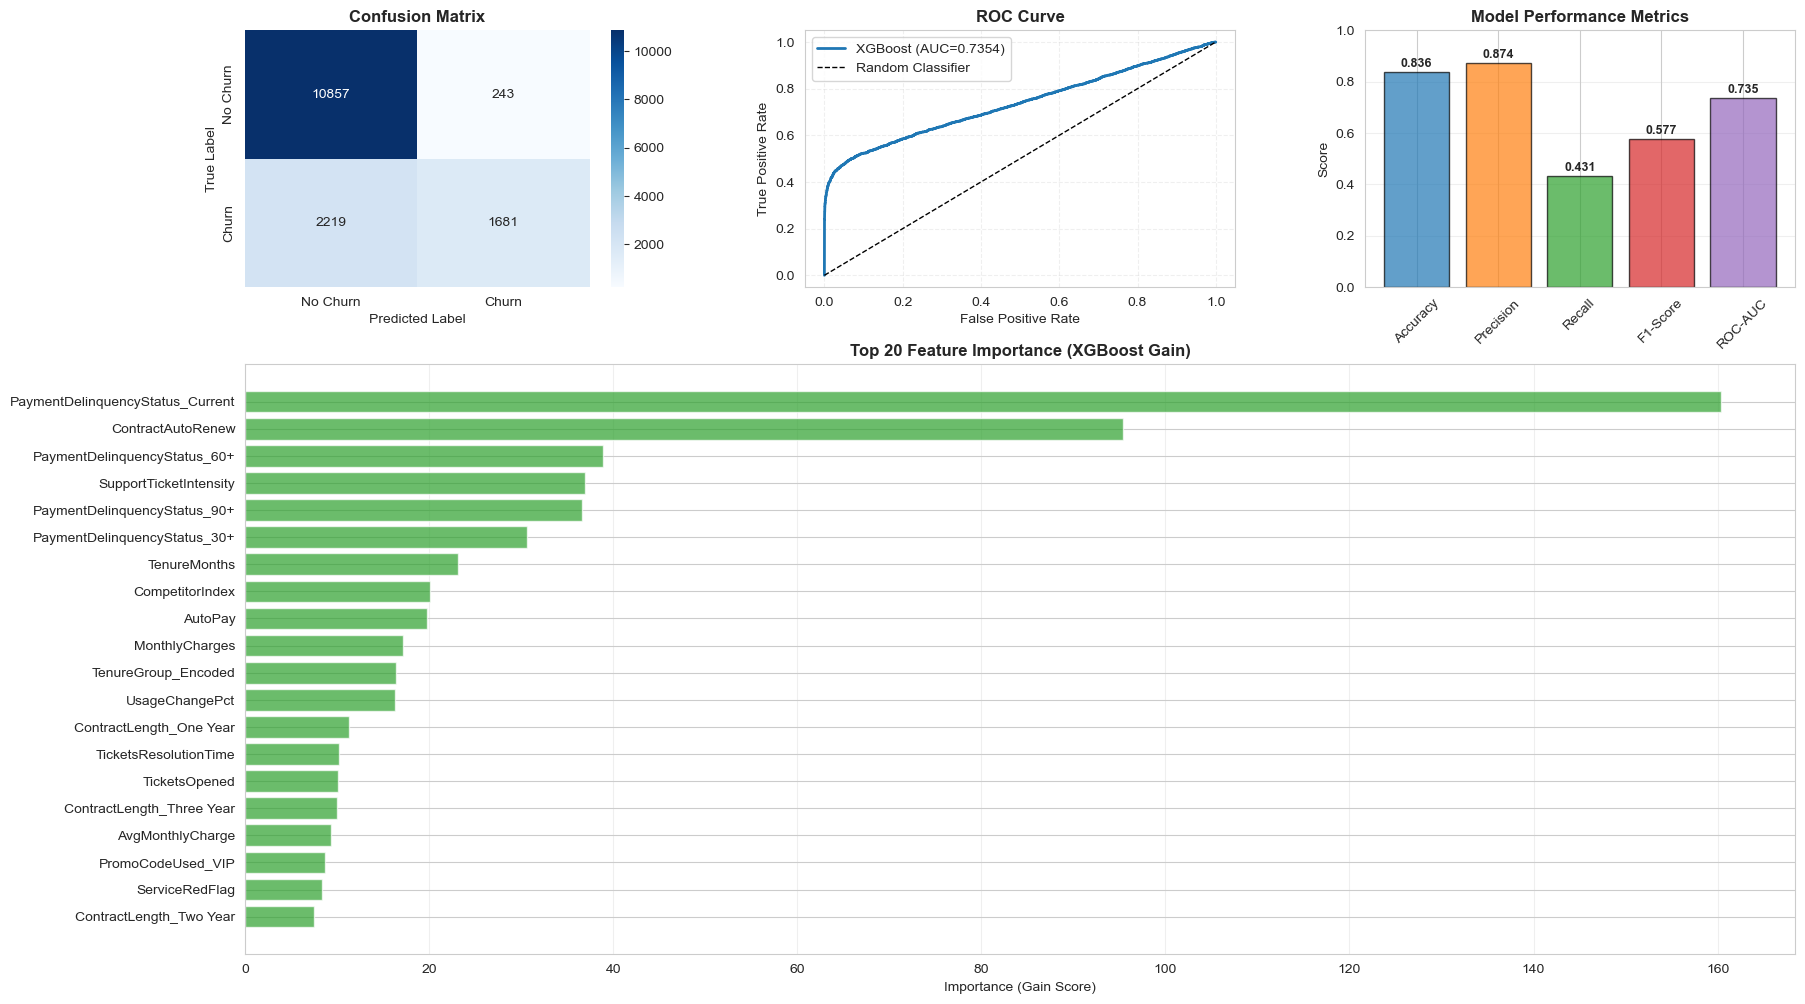

Visualization saved as 'xgboost_churn_prediction_results.png'
XGBOOST CHURN PREDICTION ANALYSIS COMPLETE!


In [154]:
#XG boost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Step 1 : LOAD AND PREPARE DATA
print("Step 1 : Data loading and preparing")

# Load the cleaned dataset
df = pd.read_excel('C:\Windows\System32\Srishti\IS6052\Final\Omni_Churn_Data_Prepared.xlsx')

print(f"Dataset Shape: {df.shape}")
print(f"Target Variable (Churn) Distribution:")
print(df['Churn'].value_counts())
print()

# Separate features and target
X = df.drop(['CustomerID', 'Churn'], axis=1)
y = df['Churn']

print(f"Features: {X.shape[1]} columns")
print(f"Samples: {X.shape[0]} rows")
print()

# Step 2 Encode categorical variable
print("STEP 2: ENCODING CATEGORICAL VARIABLES")


# One-hot encoding for categorical variables
X = pd.get_dummies(X, columns=X.select_dtypes(include=['object']).columns, drop_first=True)

# Filling missing values
X = X.fillna(X.mean())

print(f"Features after encoding: {X.shape[1]} columns")
print()

# Step 3 : TRAIN-TEST SPLIT
print("STEP 3: TRAIN-TEST SPLIT")

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Training Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print()

# Step 4 Hyperparameter tuning with gridsearchcv
print("STEP 4: Hyperparameter tuning")

# Define cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Define parameter grid for XGBoost tuning
param_grid = {
    'n_estimators': [100, 200],                # Number of boosting rounds
    'max_depth': [3, 5, 7],                    # Tree depth
    'learning_rate': [0.05, 0.1, 0.2],         # Shrinkage (eta)
    'subsample': [0.8, 1.0],                   # Row sampling
    'colsample_bytree': [0.8, 1.0]             # Column sampling
}

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

# Perform grid search
print("Tuning XGBoost parameters...")
print("Note: This may take 5-20 minutes depending on data size")

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
best_cv_score = grid_search.best_score_
best_params = grid_search.best_params_

print(f"\nBest Cross-Validation ROC-AUC: {best_cv_score:.4f}")
print(f"Best Parameters: {best_params}")
print()

# STEP 5: MODEL EVALUATION
print("STEP 5: Model evaluation")

# Make predictions
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print()


# STEP 6: CONFUSION MATRIX ANALYSIS
print("STEP 6: CONFUSION MATRIX ANALYSIS")

conf_matrix = confusion_matrix(y_test, y_pred)
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

print(f"True Positives (Correct Churners): {TP}")
print(f"True Negatives (Correct Non-Churners): {TN}")
print(f"False Positives (Loyal flagged as churn): {FP}")
print(f"False Negatives (Missed churners): {FN}")
print()
print(f"Sensitivity (Recall): {TP/(TP+FN):.4f} - Proportion of actual churners identified")
print(f"Specificity: {TN/(TN+FP):.4f} - Proportion of non-churners correctly identified")
print()

# STEP 7: FEATURE IMPORTANCE
print("STEP 7: FEATURE IMPORTANCE")

# Get feature importance from XGBoost
feature_importance = best_xgb.get_booster().get_score(importance_type='gain')

# Convert to DataFrame
importance_df = pd.DataFrame(
    list(feature_importance.items()),
    columns=['Feature', 'Importance']
).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))
print()

# STEP 8: VISUALIZATION
print("Step 8 Visualization")
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Row 1, Col 1: Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# Row 1, Col 2: ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC={roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(linestyle='--', alpha=0.3)

# Row 1, Col 3: Metrics Comparison
ax3 = fig.add_subplot(gs[0, 2])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
ax3.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')
ax3.set_ylim([0, 1])
ax3.set_ylabel('Score')
ax3.set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)
for i, v in enumerate(metrics_values):
    ax3.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)


# Row 2-3: Feature Importance (Top 20 features)
ax4 = fig.add_subplot(gs[1:, :])
top_20_features = importance_df.head(20)
ax4.barh(range(len(top_20_features)), top_20_features['Importance'].values, color='#2ca02c', alpha=0.7)
ax4.set_yticks(range(len(top_20_features)))
ax4.set_yticklabels(top_20_features['Feature'].values)
ax4.set_xlabel('Importance (Gain Score)')
ax4.set_title('Top 20 Feature Importance (XGBoost Gain)', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
ax4.invert_yaxis()

plt.savefig('xgboost_churn_prediction_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'xgboost_churn_prediction_results.png'")
print("=" * 80)
print("XGBOOST CHURN PREDICTION ANALYSIS COMPLETE!")
